# Dark-matter quantum-sensor response analysis

Forward + inverse analysis of the detector response, organised **by detector**
and, within each, **by velocity-distribution model**. Same pipeline throughout
(load Mathematica response matrix -> forward model `exposure * M @ eta` ->
recover the monotone non-negative flux `x(v_min)`); only two things change:

- **detector** (`material`): **TES (Al)** -- Mermin, 0.1 eV threshold, fine `R10`;
  **MKID (TiN)** -- Lindhard, 0.2 eV threshold, fine `R9`.
- **velocity model**: **Halo** -- standard halo (SHM, `v0=238, ve=250, vesc=544`
  km/s); **pure dark disk** -- same DM density, colder (`v0=70, ve=100,
  vesc=694`). The actual **best-fit uses a mixture** `eta = (1-p)*Halo + p*Disk`
  with disk fraction `p`; because both components carry the same local DM
  density, the mixture's density equals 100% SHM for any `p`. A third model,
  **Bound** (Earth-captured thermal DM), is a separate dense population
  (`rho_b`, isotropic, `vesc=11.2` km/s) -- only the heaviest mass (1 GeV) has
  any signal, since the bound DM is too slow to reach higher `v_min`.

The mixture sections sweep `p` over `DISK_FRACTIONS` and overlay, on each fit,
the **100% SHM** halo and the **`p` x pure disk** component for reference.


In [48]:
%matplotlib inline
import matplotlib.pyplot as plt
from quantum_sensor import DarkMatterQuantumAnalysis, RunConfig

MASS_LABELS = {'1': '10 MeV', '2': '100 MeV', '3': '1 GeV'}
DETECTOR = {'Al': 'TES', 'TiN': 'MKID'}
# Dark-disk mixing fractions p for the best-fit eta = (1-p)*Halo + p*Disk.
DISK_FRACTIONS = (0.05, 0.25)


def run_masses(material, q='0', nbins=5, eta='Halo', background='none',
               disk_fraction=None, masses=('1', '2', '3'), solver='osqp', save=True):
    """Run the forward+inverse analysis for several DM masses.

    Shows one combined figure (the masses side by side). When ``save=True``
    (default) each run is ALSO saved on its own -- flux.csv plus an individual
    flux.pdf -- into its per-run folder
    results/<DET>/bkg-<background>/<material>_q<q>_M<mass>_R<nbins>_<eta>/, so
    every type is stored separately regardless of the combined display.
    """
    fig, axes = plt.subplots(1, len(masses), figsize=(6 * len(masses), 5), squeeze=False)
    for ax, mass in zip(axes[0], masses):
        a = DarkMatterQuantumAnalysis(
            RunConfig(material=material, q=q, mass=mass, nbins=nbins,
                      eta=eta, disk_fraction=disk_fraction, background=background))
        flux = a.optimize(solver=solver)
        print('signal     :', a.signal)
        print('background :', a.background)

        if save:
            a.save_flux()                     # flux.csv in this run's own folder
            sfig, sax = plt.subplots(figsize=(8, 6))
            a.plot(save=True, ax=sax)         # individual flux.pdf next to the CSV
            plt.close(sfig)                   # keep only the combined figure on screen

        a.plot(save=False, ax=ax)             # combined panel (display only)
        ax.set_title(f'{material} ({DETECTOR[material]}), $m_\\chi$ = {MASS_LABELS[mass]}',
                     fontsize=13)
        print(f'{material} q{q} M{mass} R{nbins}: {a.n_ebins} E-bins x '
              f'{a.n_vmin} v_min bins, peak flux {flux.max():.2e}')
    model = eta if disk_fraction is None else f'mix {round(disk_fraction*100)}% disk'
    fig.suptitle(f'{material} ({DETECTOR[material]}), q{q}, R{nbins}, {model}, bkg={background}',
                 fontsize=14)
    plt.tight_layout(); plt.show()


# TES (Al)

## Halo (SHM) — reference

### Heavy mediator (q0), 5 energy bins

signal     : [1483.94095679 2801.77615753 3370.34959793 4454.28220081 5483.86653894]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R5_Halo/flux.pdf
Al q0 M1 R5: 5 E-bins x 126 v_min bins, peak flux 7.89e+02
signal     : [ 73.68872532 244.35997458 361.96924782 507.2587095  670.16774927]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R5_Halo/flux.pdf
Al q0 M2 R5: 5 E-bins x 63 v_min bins, peak flux 8.27e+01
signal     : [ 7.95434682 13.6379113  20.62444319 27.13766908 33.94541164]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R5_Halo/flux.pdf
Al q0 M3 R5: 5 E-bins x 49 v_min bins, peak flux 8.28e+00


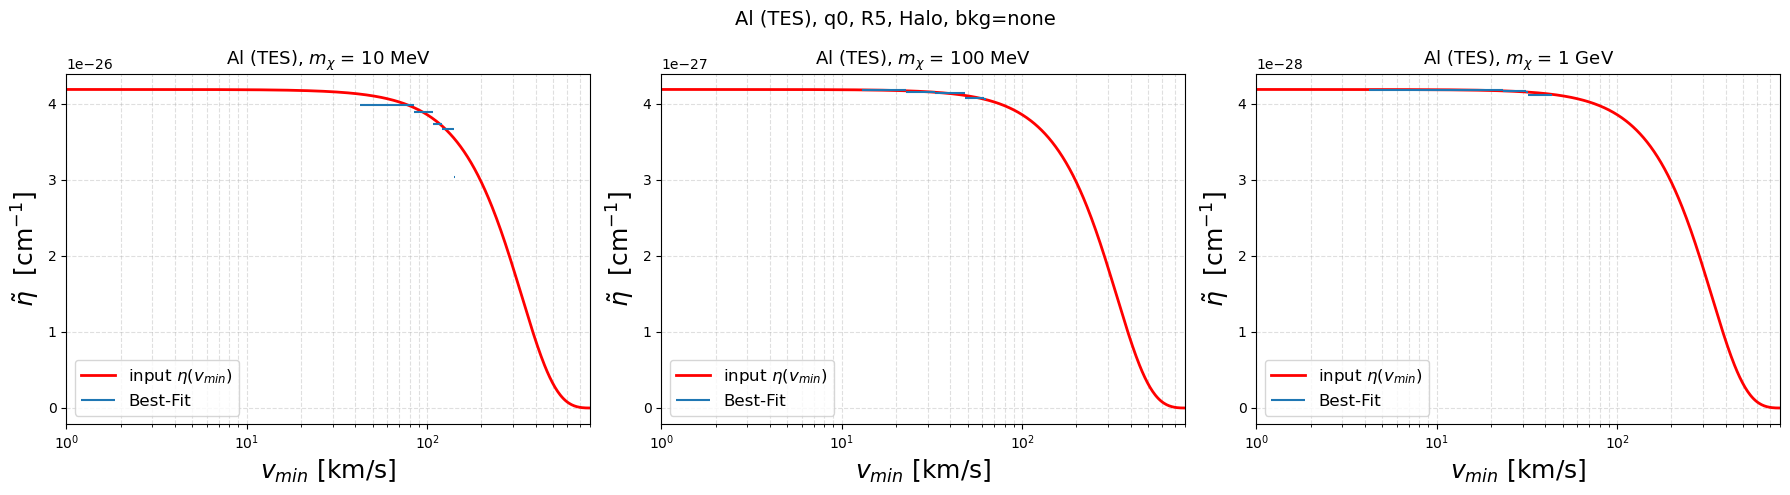

In [49]:
run_masses('Al', q='0', nbins=5, eta='Halo', solver = 'scipy')

### Light mediator (q2), 5 energy bins

signal     : [1201.10202569 1907.46481671 2357.63241039 2680.56381363 2930.92793898]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R5_Halo/flux.pdf
Al q2 M1 R5: 5 E-bins x 134 v_min bins, peak flux 8.00e+02
signal     : [ 78.95174604 137.31916943 195.9737239  248.56240422 298.57060325]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R5_Halo/flux.pdf
Al q2 M2 R5: 5 E-bins x 121 v_min bins, peak flux 8.25e+01
signal     : [ 7.50267088 14.03005819 19.74662368 25.12955046 30.08706198]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R5_Halo/flux.pdf
Al q2 M3 R5: 5 E-bins x 128 v_min bins, peak flux 8.27e+00


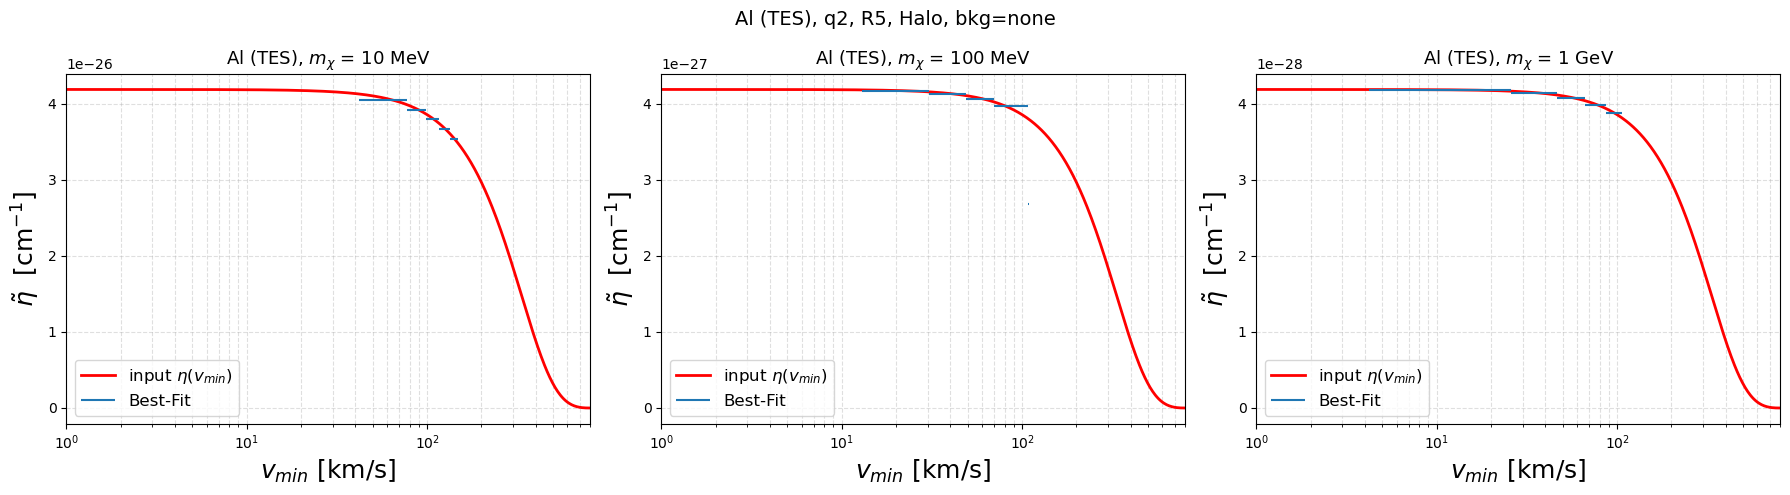

In [50]:
run_masses('Al', q='2', nbins=5, eta='Halo', solver = 'scipy')

### Heavy mediator (q0), 10 energy bins

signal     : [ 594.63468321  996.42280456 1359.24747095 1699.17205522 1299.58576059
 1557.36888243 1758.64179761 2001.31513879 2216.39264251 2563.7398015 ]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R10_Halo/flux.pdf
Al q0 M1 R10: 10 E-bins x 127 v_min bins, peak flux 8.05e+02
signal     : [ 30.96514325  80.36488814  96.76623644 114.49147325 157.23547028
 191.93538798 232.591103   281.43834617 329.87204378 367.06734709]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R10_Halo/flux.pdf
Al q0 M2 R10: 10 E-bins x 65 v_min bins, peak flux 8.27e+01
signal     : [ 2.9936656   4.53122424  6.33463387  7.99831326  9.90728492 11.56705009
 13.38739188 15.19158769 16.89138616 18.70882733]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Quan

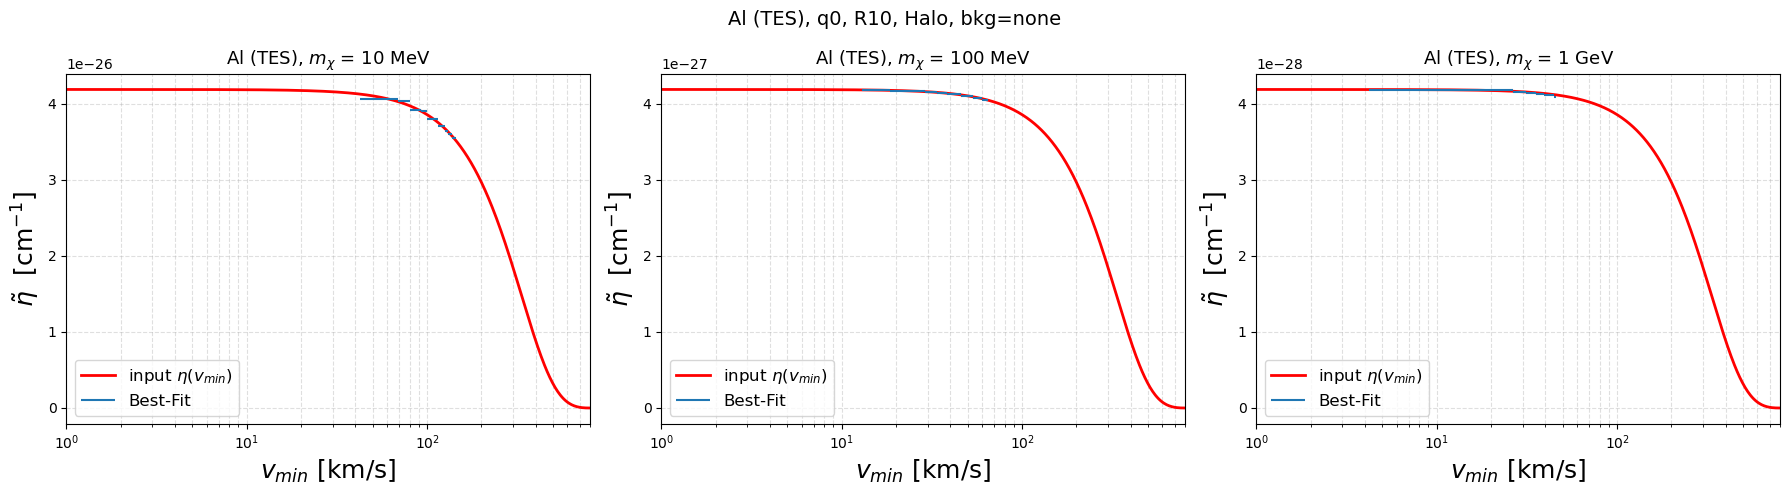

In [51]:
run_masses('Al', q='0', nbins=10, eta='Halo', solver = 'scipy')

### Light mediator (q2), 10 energy bins

signal     : [ 417.48827588  628.66069243  779.72146076  911.58269343 1032.45868239
 1138.31890904 1236.77798819 1376.27112888 1445.64292062 1559.63002557]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R10_Halo/flux.pdf
Al q2 M1 R10: 10 E-bins x 138 v_min bins, peak flux 8.08e+02
signal     : [ 28.38372022  45.47502348  60.87843376  76.64710651  91.5880468
 106.43632136 120.35799166 133.48679586 146.91177006 159.42950338]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R10_Halo/flux.pdf
Al q2 M2 R10: 10 E-bins x 125 v_min bins, peak flux 8.27e+01
signal     : [ 2.85465144  4.63927331  6.22749507  7.80529667  9.30442911 10.74811249
 12.19177916 13.47035238 14.77649597 16.08300662]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Quan

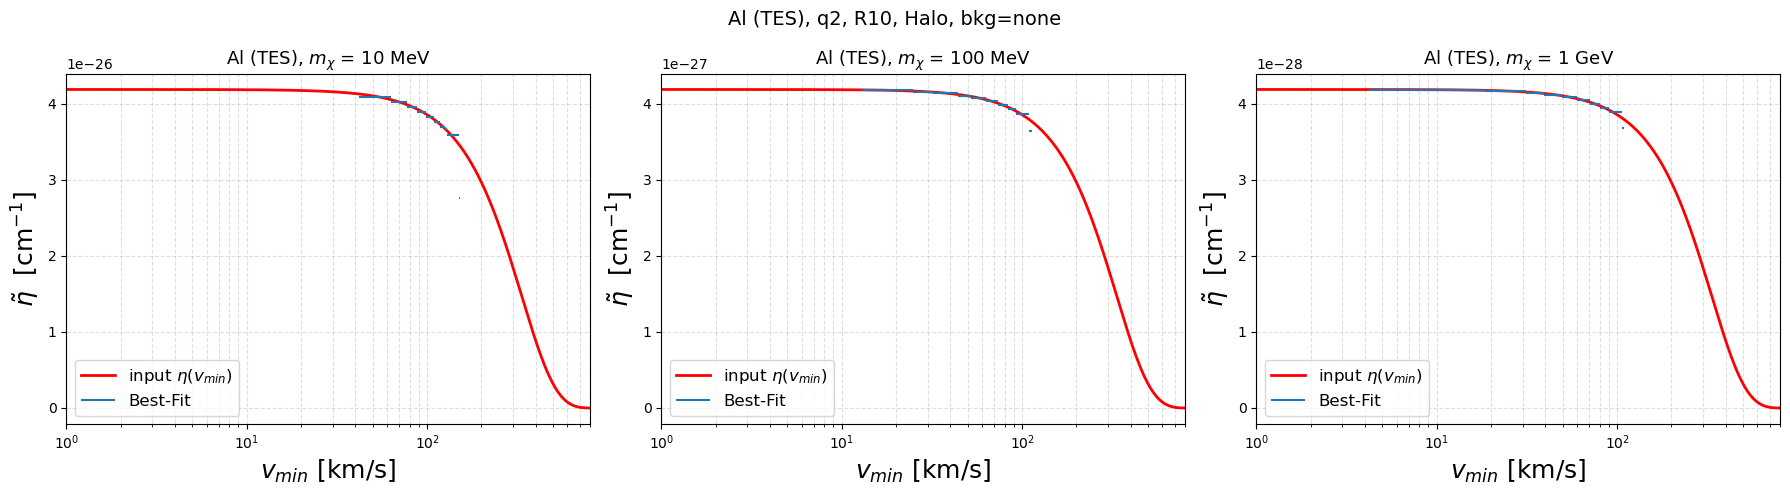

In [52]:
run_masses('Al', q='2', nbins=10, eta='Halo', solver = 'scipy')

## Mixture (best-fit) — sweep dark-disk fraction

`eta = (1-p)*Halo + p*Disk`. Each figure overlays 100% SHM (gray) and `p` x pure disk (green).

### Heavy mediator (q0), 5 energy bins

signal     : [1543.18080633 2878.61560123 3422.16343822 4457.91922009 5419.50156242]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R5_mix5/flux.pdf
Al q0 M1 R5: 5 E-bins x 126 v_min bins, peak flux 8.31e+02
signal     : [ 80.02482198 264.67317476 390.90925627 545.88415369 718.15586023]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R5_mix5/flux.pdf
Al q0 M2 R5: 5 E-bins x 63 v_min bins, peak flux 8.98e+01
signal     : [ 8.6488199  14.82382815 22.40557958 29.46076334 36.81661479]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R5_mix5/flux.pdf
Al q0 M3 R5: 5 E-bins x 49 v_min bins, peak flux 9.01e+00


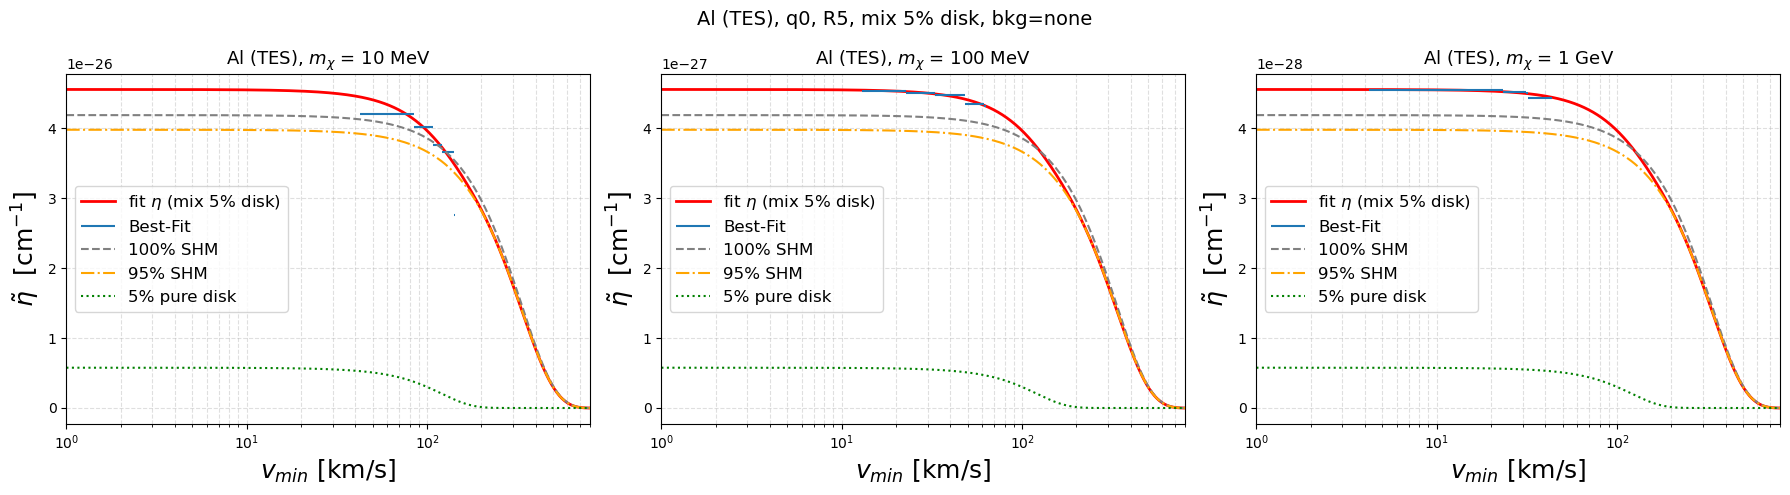

signal     : [1780.14020451 3185.97337605 3629.41879938 4472.46729723 5162.04165635]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R5_mix25/flux.pdf
Al q0 M1 R5: 5 E-bins x 126 v_min bins, peak flux 9.99e+02
signal     : [105.36920865 345.92597547 506.66929006 700.38593047 910.10830405]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R5_mix25/flux.pdf
Al q0 M2 R5: 5 E-bins x 63 v_min bins, peak flux 1.18e+02
signal     : [11.42671225 19.56749556 29.53012515 38.75314038 48.3014274 ]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R5_mix25/flux.pdf
Al q0 M3 R5: 5 E-bins x 49 v_min bins, peak flux 1.19e+01


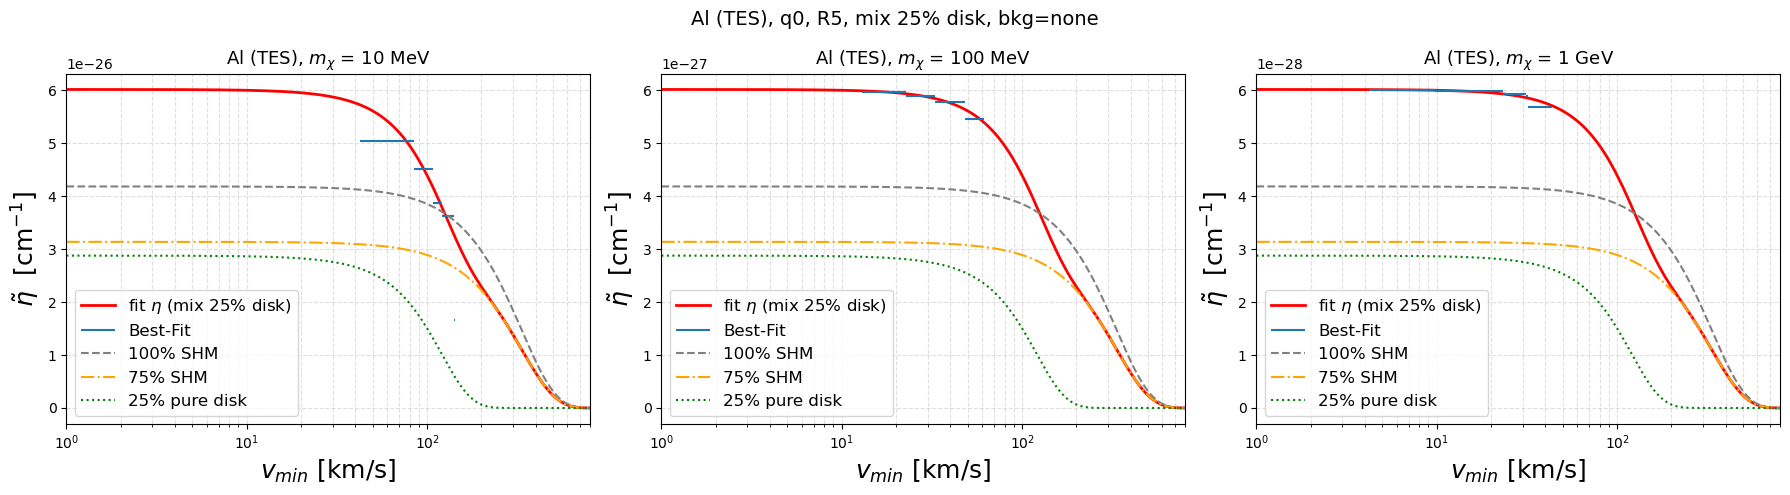

In [53]:
for p in DISK_FRACTIONS:
    run_masses('Al', q='0', nbins=5, disk_fraction=p, solver = 'scipy')

### Light mediator (q2), 5 energy bins

signal     : [1276.38328032 1985.36938586 2404.09714375 2684.87962158 2893.07856237]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R5_mix5/flux.pdf
Al q2 M1 R5: 5 E-bins x 134 v_min bins, peak flux 8.50e+02
signal     : [ 85.64992649 148.2982915  210.07509791 263.79424165 312.97933683]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R5_mix5/flux.pdf
Al q2 M2 R5: 5 E-bins x 121 v_min bins, peak flux 8.95e+01
signal     : [ 8.14760401 15.17801887 21.22618468 26.76787902 31.68555196]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R5_mix5/flux.pdf
Al q2 M3 R5: 5 E-bins x 128 v_min bins, peak flux 8.98e+00


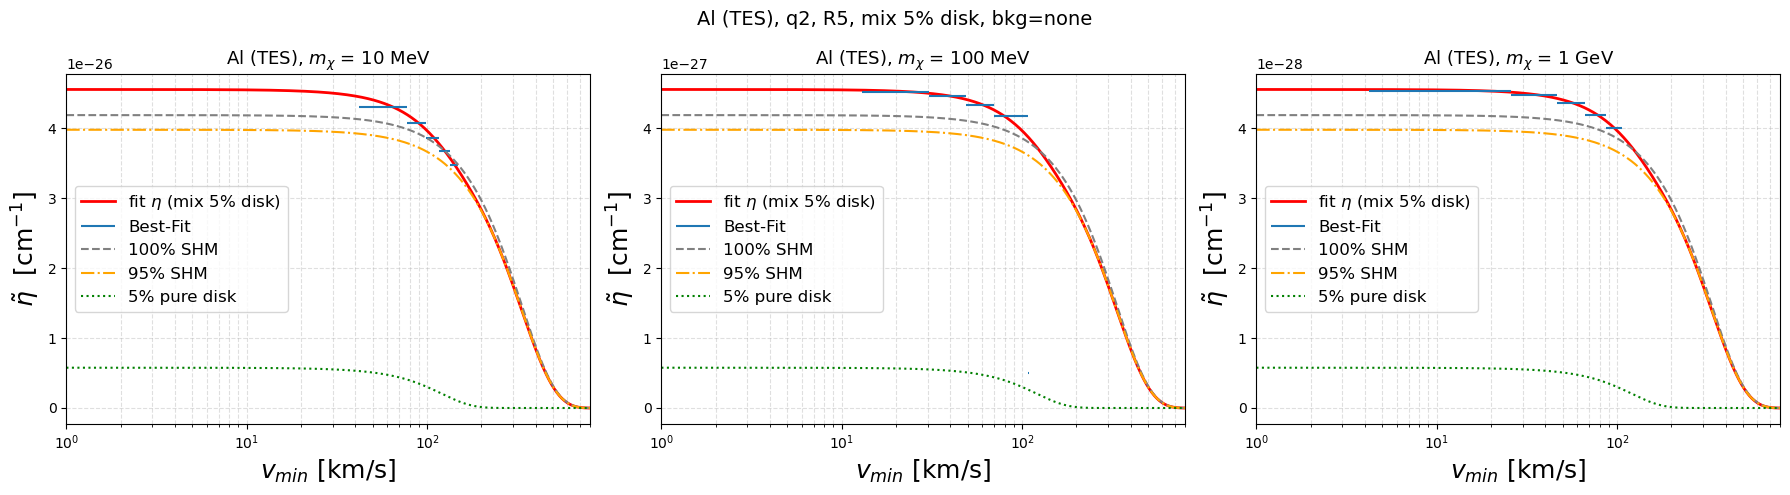

signal     : [1577.50829884 2296.98766245 2589.95607716 2702.14285338 2741.68105593]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R5_mix25/flux.pdf
Al q2 M1 R5: 5 E-bins x 134 v_min bins, peak flux 1.05e+03
signal     : [112.44264832 192.21477981 266.48059395 324.72159134 370.61427114]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R5_mix25/flux.pdf
Al q2 M2 R5: 5 E-bins x 121 v_min bins, peak flux 1.18e+02
signal     : [10.72733654 19.76986158 27.14442868 33.32119328 38.07951186]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R5_mix25/flux.pdf
Al q2 M3 R5: 5 E-bins x 128 v_min bins, peak flux 1.18e+01


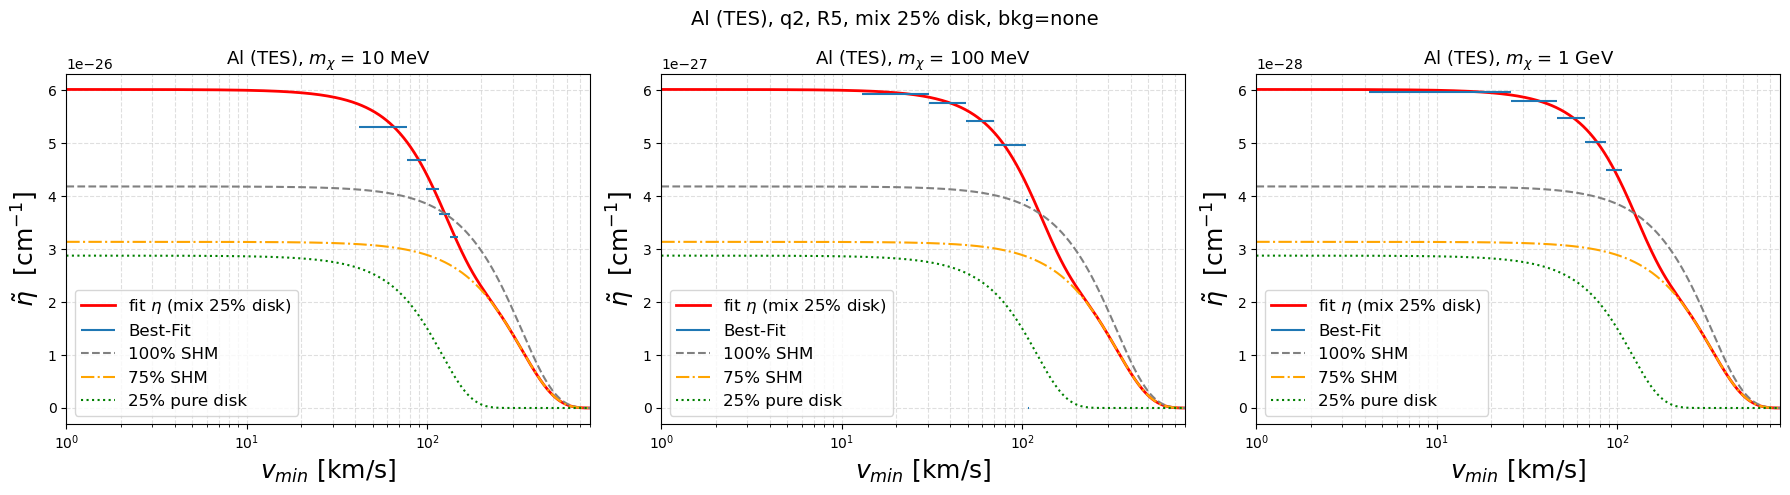

In [54]:
for p in DISK_FRACTIONS:
    run_masses('Al', q='2', nbins=5, disk_fraction=p)

### Heavy mediator (q0), 10 energy bins

signal     : [ 620.39323262 1033.42406392 1400.69995672 1739.21977736 1327.77493083
 1578.2125768  1768.88350953 1998.35009508 2198.61179508 2527.57494047]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R10_mix5/flux.pdf
Al q0 M1 R10: 10 E-bins x 127 v_min bins, peak flux 8.59e+02
signal     : [ 33.63729531  87.20499456 104.88779744 123.94449829 169.95368126
 207.13083032 250.56043493 302.57168961 353.86651519 392.92099254]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R10_mix5/flux.pdf
Al q0 M2 R10: 10 E-bins x 65 v_min bins, peak flux 8.98e+01
signal     : [ 3.25523377  4.92652523  6.88605406  8.69281183 10.764416   12.56405408
 14.53590752 16.48784904 18.32458281 20.28523484]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Quan

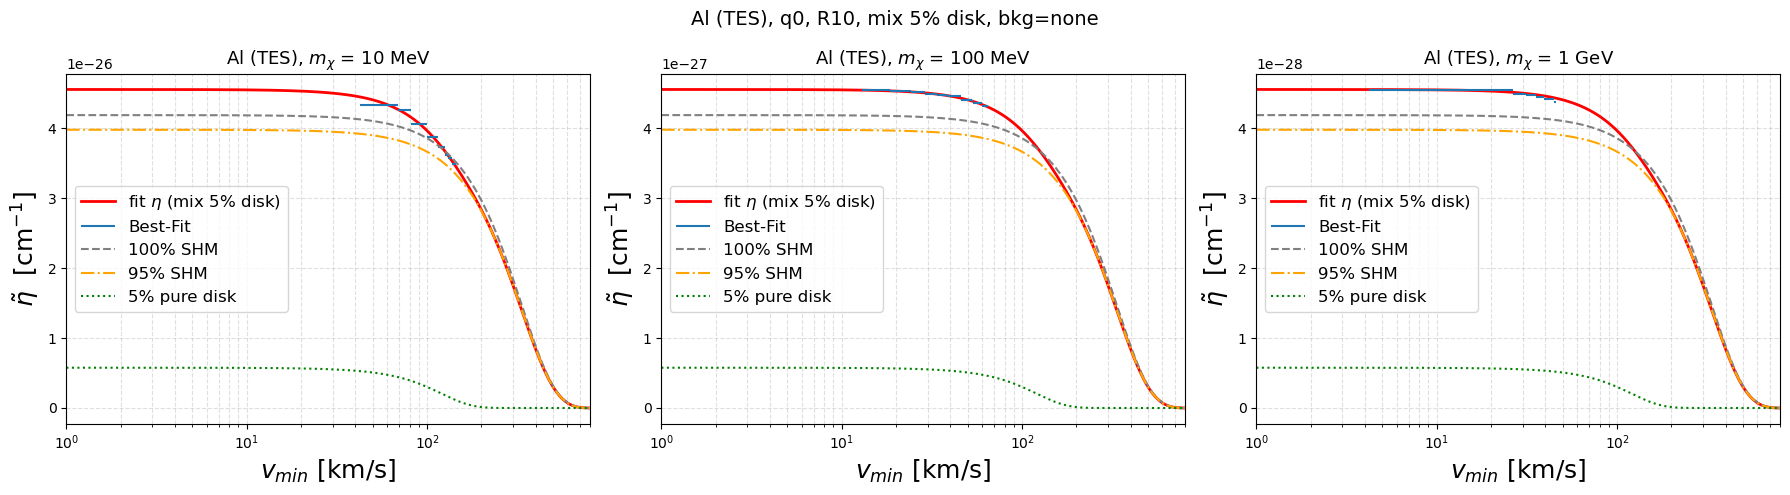

signal     : [ 723.42743028 1181.42910135 1566.50989979 1899.41066591 1440.53161179
 1661.58735428 1809.8503572  1986.48992026 2127.48840537 2382.91549634]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R10_mix25/flux.pdf
Al q0 M1 R10: 10 E-bins x 127 v_min bins, peak flux 1.08e+03
signal     : [ 44.32590356 114.56542022 137.37404143 161.75659848 220.82652521
 267.9125997  322.43776262 387.10506337 449.84440087 496.33557435]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R10_mix25/flux.pdf
Al q0 M2 R10: 10 E-bins x 65 v_min bins, peak flux 1.18e+02
signal     : [ 4.30150646  6.50772921  9.09173482 11.4708061  14.19294034 16.55207002
 19.12997008 21.67289444 24.05736942 26.59086486]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Qu

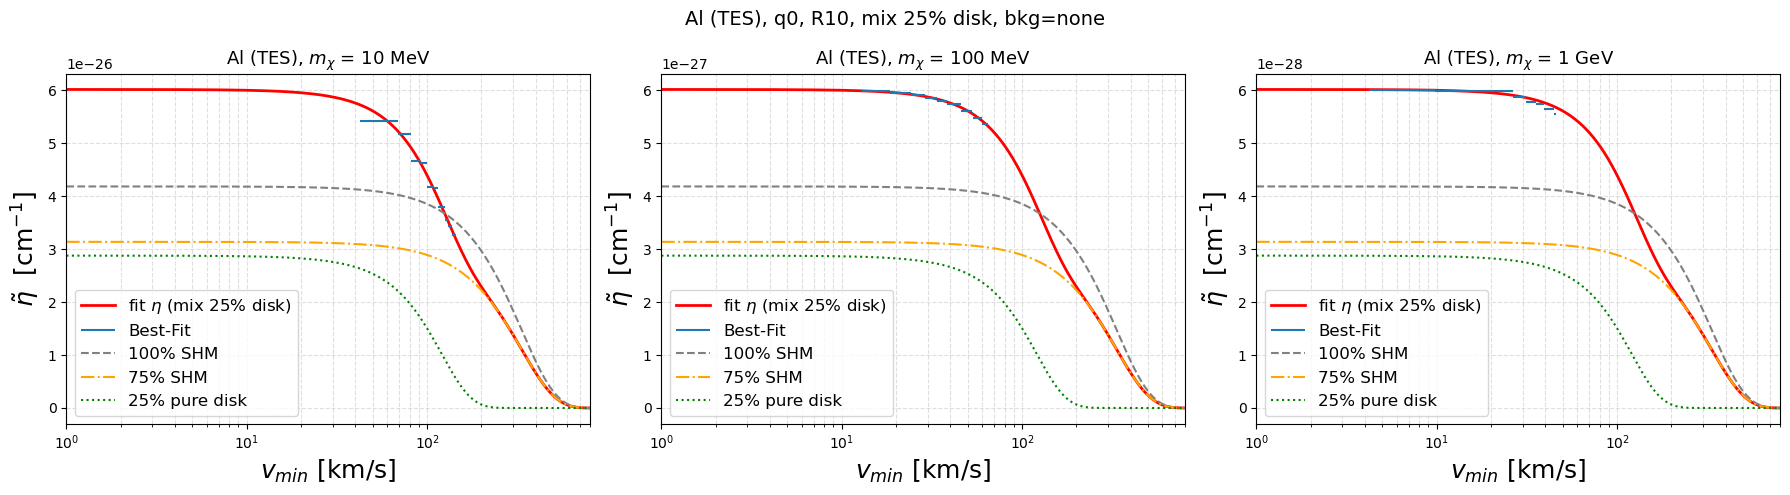

In [55]:
for p in DISK_FRACTIONS:
    run_masses('Al', q='0', nbins=10, disk_fraction=p, solver = 'scipy')

### Light mediator (q2), 10 energy bins

signal     : [ 446.74852414  665.84696799  816.88494218  944.68891877 1058.84958172
 1155.91606526 1244.53721113 1373.20383499 1431.74042442 1534.60563879]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R10_mix5/flux.pdf
Al q2 M1 R10: 10 E-bins x 138 v_min bins, peak flux 8.65e+02
signal     : [ 30.82089895  49.29996303  65.85159837  82.66504033  98.42293879
 113.884732   128.14165928 141.33371517 154.58915036 166.66685532]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R10_mix5/flux.pdf
Al q2 M2 R10: 10 E-bins x 125 v_min bins, peak flux 8.97e+01
signal     : [ 3.10208777  5.0352452   6.74663388  8.43493443 10.02346769 11.53492191
 13.02494344 14.31910383 15.6190074  16.8944454 ]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Qua

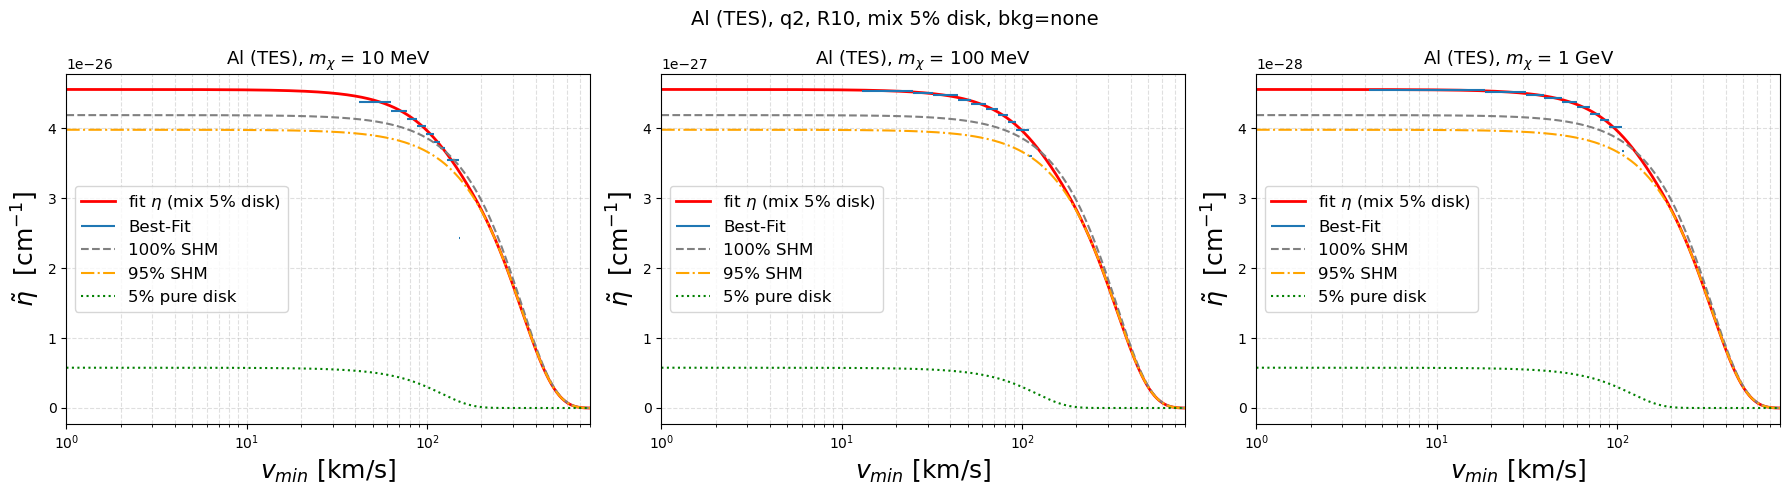

signal     : [ 563.78951719  814.5920702   965.53886789 1077.11382015 1164.41317903
 1226.30469014 1275.57410285 1360.93465947 1376.13043963 1434.50809167]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R10_mix25/flux.pdf
Al q2 M1 R10: 10 E-bins x 138 v_min bins, peak flux 1.09e+03
signal     : [ 40.56961384  64.59972122  85.74425683 106.73677564 125.76250675
 143.67837457 159.27632973 172.72139241 185.29867156 195.61626307]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R10_mix25/flux.pdf
Al q2 M2 R10: 10 E-bins x 125 v_min bins, peak flux 1.18e+02
signal     : [ 4.09183308  6.61913277  8.82318911 10.95348546 12.89962199 14.6821596
 16.35760055 17.71410963 18.98905311 20.14020052]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Qu

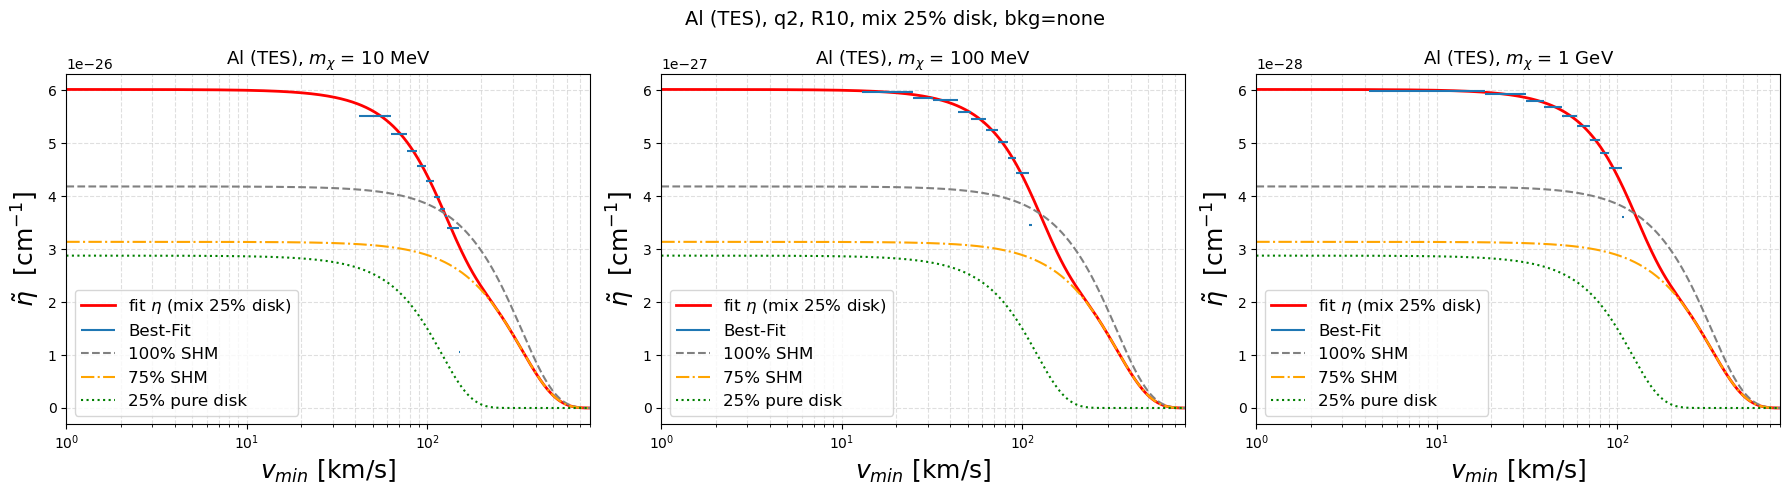

In [56]:
for p in DISK_FRACTIONS:
    run_masses('Al', q='2', nbins=10, disk_fraction=p)

## Bound (Earth-bound thermal DM)

Dense (`rho_b = 1e14` GeV/cm^3), isotropic, cold (`v0 ~ 2.16` km/s at 1 GeV), `vesc = 11.2` km/s. Only **M3 (1 GeV)** is shown: the bound population is too slow to reach the `v_min` thresholds of the lighter masses (M1/M2 have no signal).

### Heavy mediator (q0), 5 energy bins

signal     : [2.36412485e+14 2.38842861e+11 1.43354671e+08 2.06760351e+04
 3.39454116e+01]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R5_Bound/flux.pdf
Al q0 M3 R5: 5 E-bins x 49 v_min bins, peak flux 6.30e+14


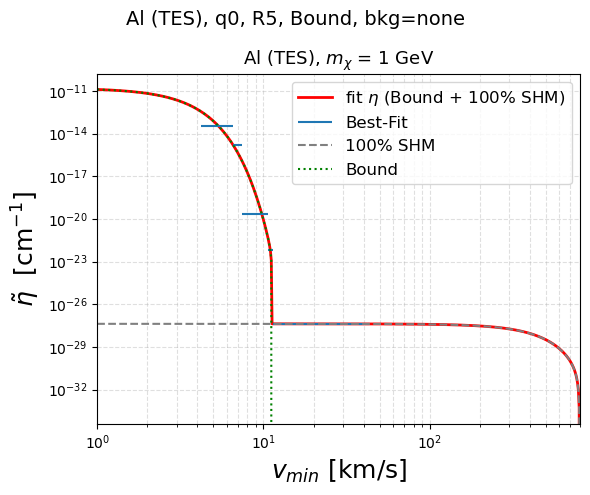

In [57]:
run_masses('Al', q='0', nbins=5, eta='Bound', masses=('3',))

### Light mediator (q2), 5 energy bins

signal     : [2.01745002e+12 1.80023127e+08 6.40243033e+04 2.84548627e+01
 3.00870620e+01]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R5_Bound/flux.pdf
Al q2 M3 R5: 5 E-bins x 128 v_min bins, peak flux 2.40e+14


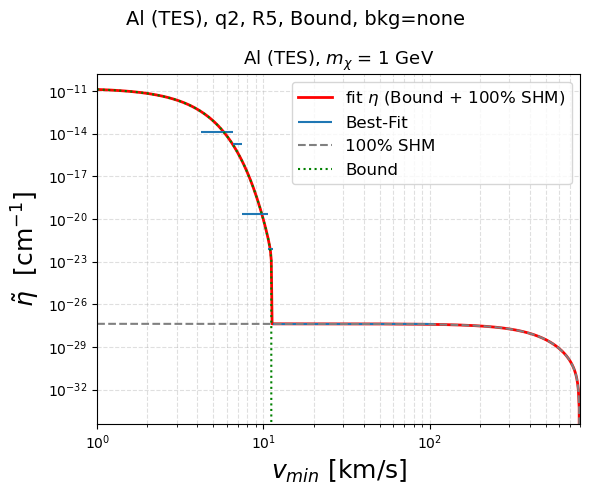

In [58]:
run_masses('Al', q='2', nbins=5, eta='Bound', masses=('3',))

### Heavy mediator (q0), 10 energy bins

signal     : [2.28564849e+14 9.73575426e+12 2.34242992e+11 6.25499599e+09
 1.41881729e+08 2.50621783e+06 2.06622848e+04 1.51915877e+01
 1.68913862e+01 1.87088273e+01]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R10_Bound/flux.pdf
Al q0 M3 R10: 10 E-bins x 52 v_min bins, peak flux 1.39e+15


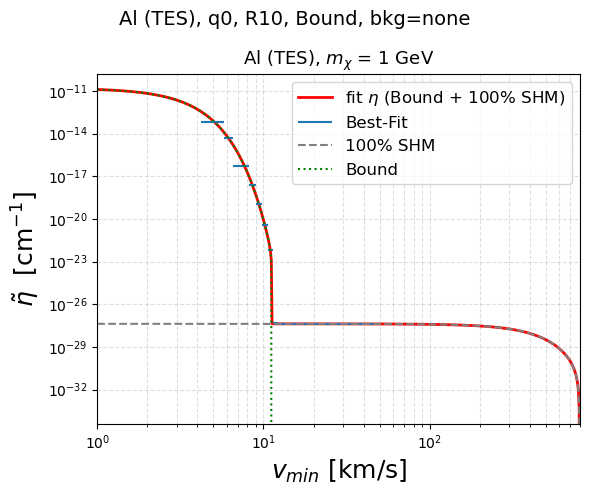

In [59]:
run_masses('Al', q='0', nbins=10, eta='Bound', masses=('3',))

### Light mediator (q2), 10 energy bins

signal     : [2.00747570e+12 1.37129880e+10 1.78148195e+08 2.70656854e+06
 6.37307124e+04 6.21370042e+02 1.55170914e+01 1.34703524e+01
 1.47764960e+01 1.60830066e+01]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R10_Bound/flux.pdf
Al q2 M3 R10: 10 E-bins x 132 v_min bins, peak flux 1.05e+15


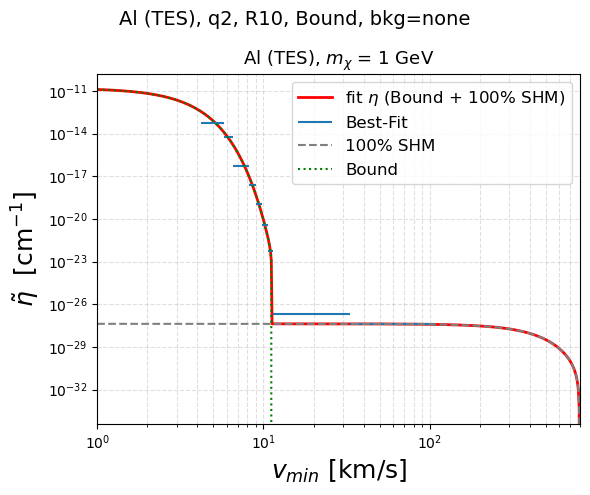

In [60]:
run_masses('Al', q='2', nbins=10, eta='Bound', masses=('3',))

## With a background scenario (Halo)

signal     : [1483.94095679 2801.77615753 3370.34959793 4454.28220081 5483.86653894]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q0 M1 R5: 5 E-bins x 126 v_min bins, peak flux 7.89e+02
signal     : [ 73.68872532 244.35997458 361.96924782 507.2587095  670.16774927]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q0 M2 R5: 5 E-bins x 63 v_min bins, peak flux 8.27e+01
signal     : [ 7.95434682 13.6379113  20.62444319 27.13766908 33.94541164]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q0 M3 R5: 5 E-bins x 49 v_min bins, peak flux 8.28e+00


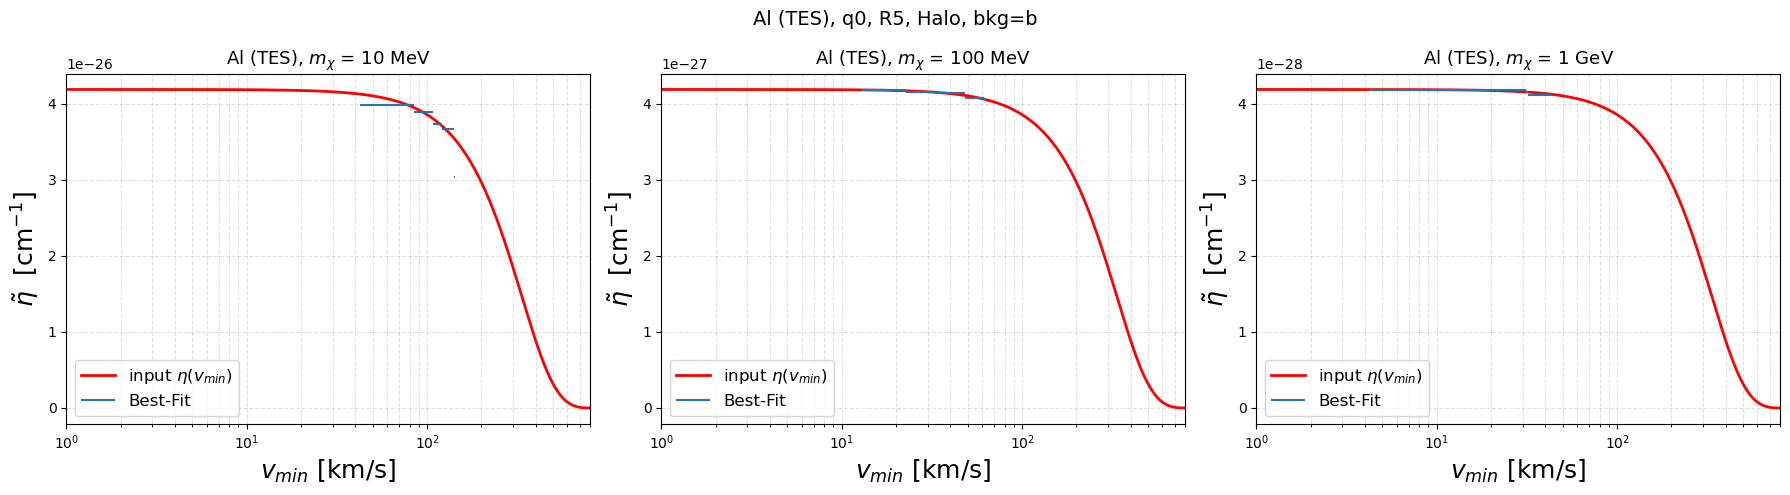

In [61]:
run_masses('Al', q='0', nbins=5, eta='Halo', background='b', solver = 'scipy', save = False)

signal     : [1201.10202569 1907.46481671 2357.63241039 2680.56381363 2930.92793898]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q2 M1 R5: 5 E-bins x 134 v_min bins, peak flux 8.00e+02
signal     : [ 78.95174604 137.31916943 195.9737239  248.56240422 298.57060325]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q2 M2 R5: 5 E-bins x 121 v_min bins, peak flux 8.25e+01
signal     : [ 7.50267088 14.03005819 19.74662368 25.12955046 30.08706198]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q2 M3 R5: 5 E-bins x 128 v_min bins, peak flux 8.27e+00


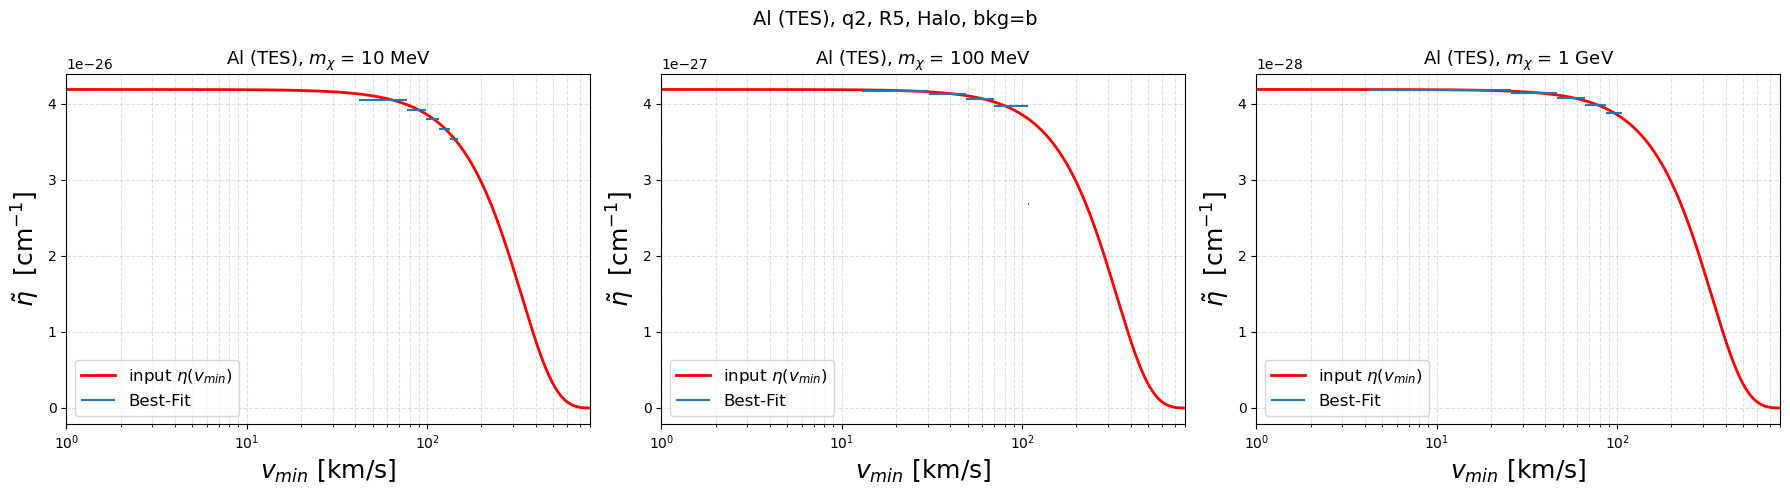

In [62]:
run_masses('Al', q='2', nbins=5, eta='Halo', background='b', save = False)

signal     : [1483.94095679 2801.77615753 3370.34959793 4454.28220081 5483.86653894]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q0 M1 R5: 5 E-bins x 126 v_min bins, peak flux 7.89e+02
signal     : [ 73.68872532 244.35997458 361.96924782 507.2587095  670.16774927]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q0 M2 R5: 5 E-bins x 63 v_min bins, peak flux 8.27e+01
signal     : [ 7.95434682 13.6379113  20.62444319 27.13766908 33.94541164]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q0 M3 R5: 5 E-bins x 49 v_min bins, peak flux 8.28e+00


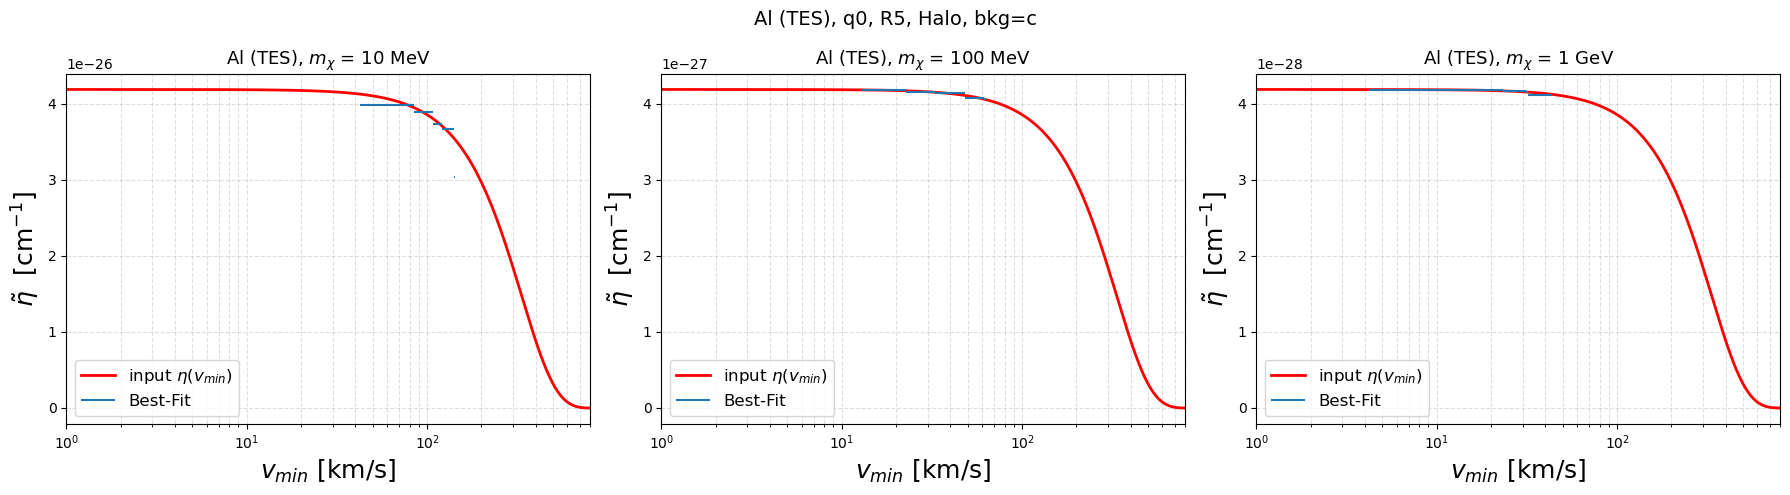

In [63]:
run_masses('Al', q='0', nbins=5, eta='Halo', background='c', solver = 'scipy', save = False)

signal     : [1201.10202569 1907.46481671 2357.63241039 2680.56381363 2930.92793898]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q2 M1 R5: 5 E-bins x 134 v_min bins, peak flux 8.00e+02
signal     : [ 78.95174604 137.31916943 195.9737239  248.56240422 298.57060325]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q2 M2 R5: 5 E-bins x 121 v_min bins, peak flux 8.25e+01
signal     : [ 7.50267088 14.03005819 19.74662368 25.12955046 30.08706198]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q2 M3 R5: 5 E-bins x 128 v_min bins, peak flux 8.27e+00


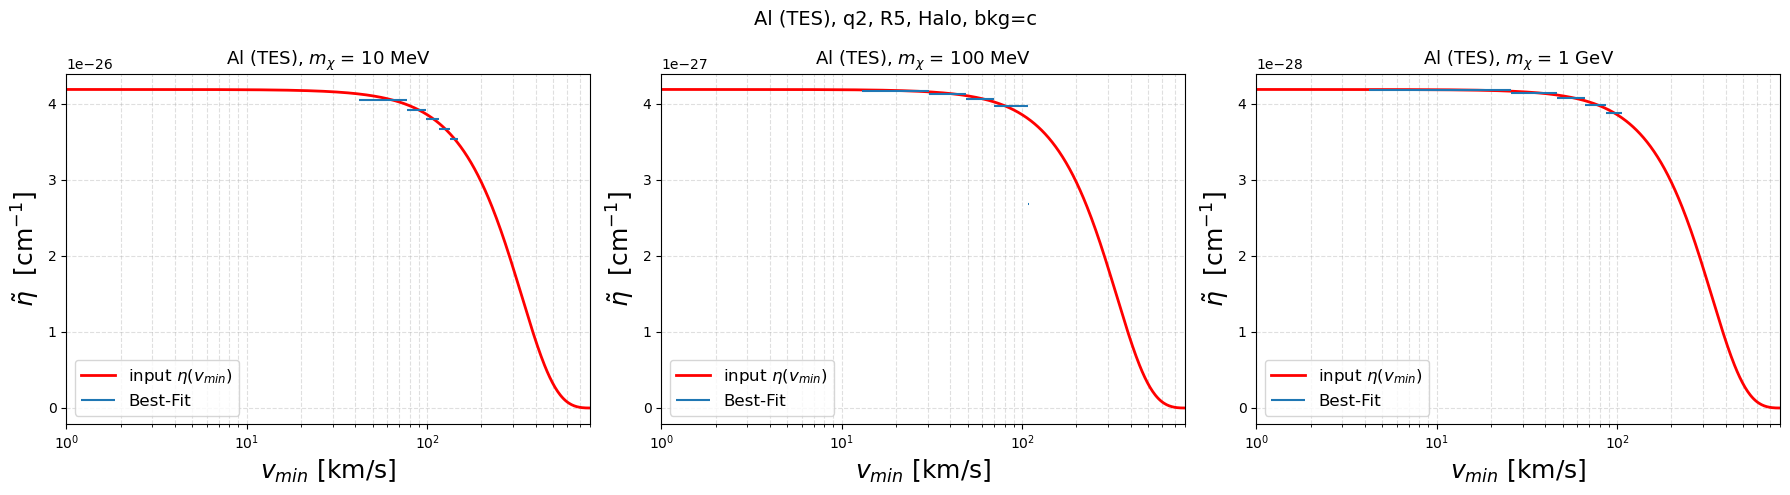

In [64]:
run_masses('Al', q='2', nbins=5, eta='Halo', background='c', save = False)

# MKID (TiN)

Titanium-nitride detector, Lindhard dielectric. Threshold **0.2 eV** (bins start at 0.2 eV, fine binning **`R9`**). Heavy mediator (`q0`) only so far.

## Halo (SHM) — reference

### Heavy mediator (q0), 5 energy bins

signal     : [ 948.43170586 2851.6190244  3412.63738337 4118.25899437 4758.04288867]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R5_Halo/flux.pdf
TiN q0 M1 R5: 5 E-bins x 110 v_min bins, peak flux 7.95e+02
signal     : [ 68.50029837 217.21982835 294.55862689 373.30136177 449.77024239]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R5_Halo/flux.pdf
TiN q0 M2 R5: 5 E-bins x 99 v_min bins, peak flux 8.24e+01
signal     : [ 6.637836   21.13327459 29.24996308 36.82757418 44.87952365]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R5_Halo/flux.pdf
TiN q0 M3 R5: 5 E-bins x 98 v_min bins, peak flux 8.26e+00


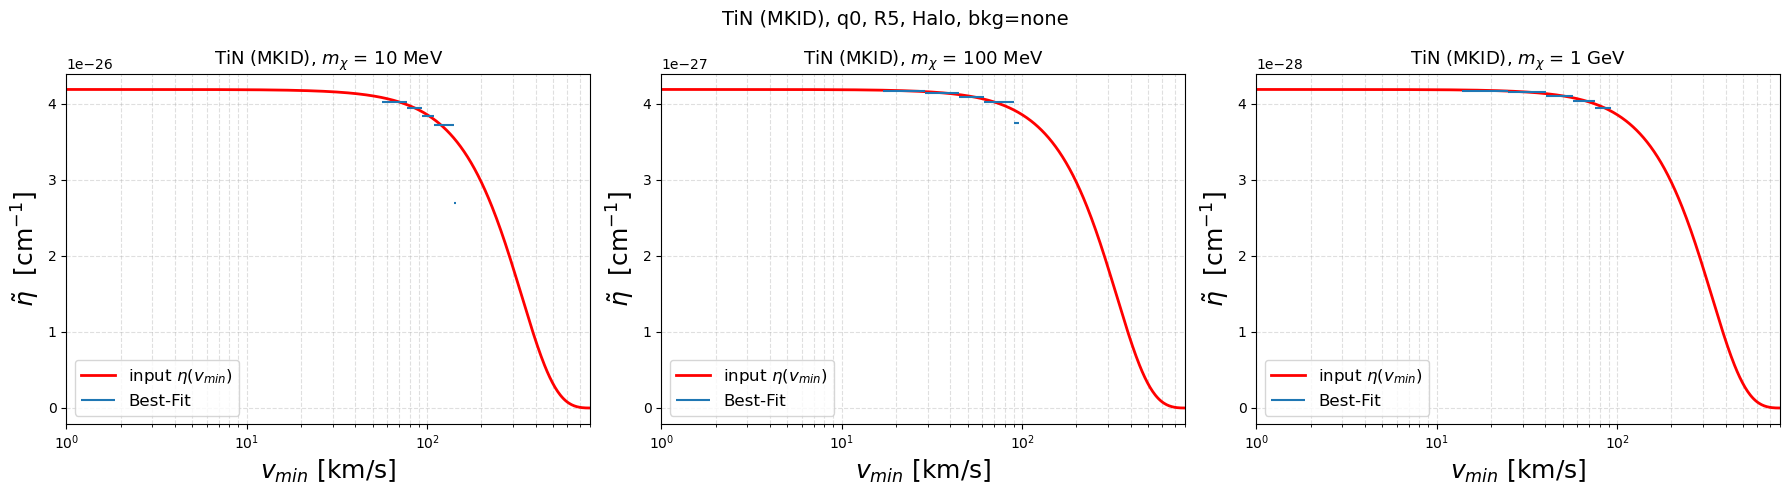

In [79]:
run_masses('TiN', q='0', nbins=5, eta='Halo', solver = 'scipy')

### Light mediator (q2), 5 energy bins

signal     : [ 4760.13607329 11775.41442823 14749.89188844 17656.38758513
 19759.41703524]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M1_R5_Halo/flux.pdf
TiN q2 M1 R5: 5 E-bins x 158 v_min bins, peak flux 7.96e+02
signal     : [ 370.04530982 1067.62142481 1444.76259401 1759.37715    2015.91194538]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M2_R5_Halo/flux.pdf
TiN q2 M2 R5: 5 E-bins x 176 v_min bins, peak flux 8.20e+01
signal     : [ 36.99991699 106.8045798  144.33791235 176.07446562 202.44148678]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M3_R5_Halo/flux.pdf
TiN q2 M3 R5: 5 E-bins x 177 v_min bins, peak flux 8.22e+00


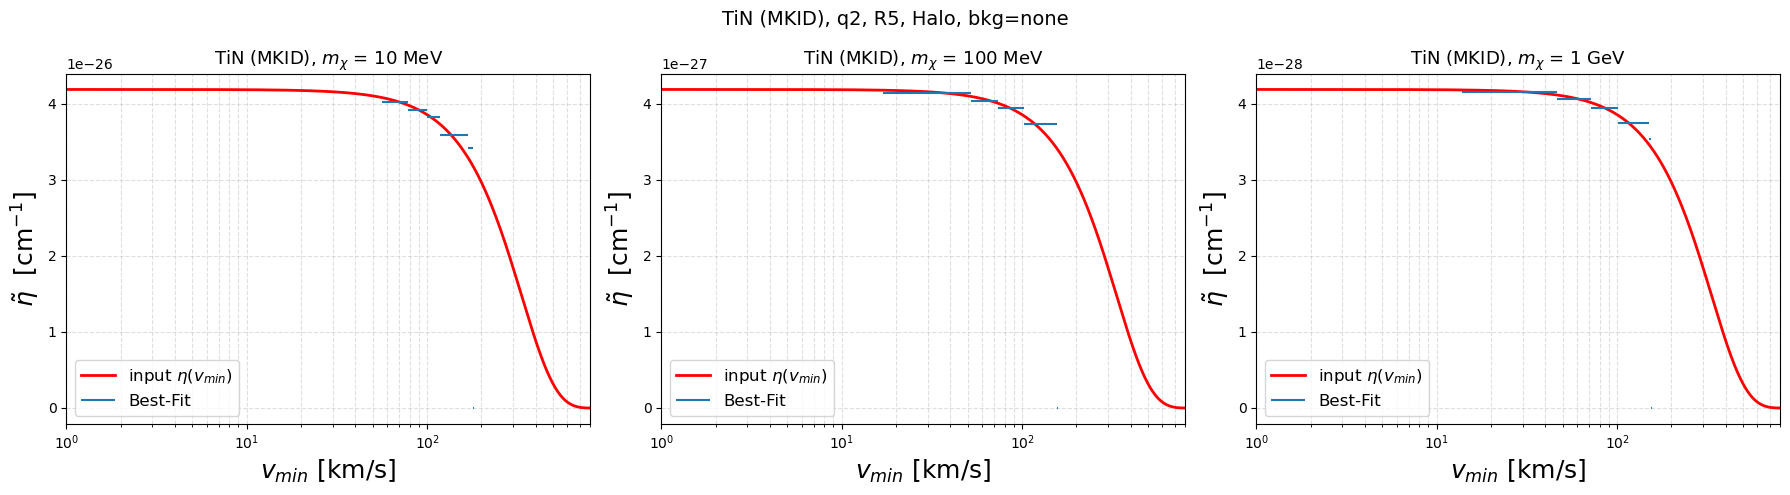

In [66]:
run_masses('TiN', q='2', nbins=5, eta='Halo')

### Heavy mediator (q0), 9 energy bins

signal     : [ 948.43170586 1232.00819541 1375.05821749 1636.18672971 1826.77806885
 2107.15016343 2322.36501909 2452.50916745 2615.71280664]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R9_Halo/flux.pdf
TiN q0 M1 R9: 9 E-bins x 115 v_min bins, peak flux 7.95e+02
signal     : [ 68.50029837  90.11825352 112.60466417 134.36004484 157.64964055
 178.27096325 200.43341742 221.9322475  240.71426488]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R9_Halo/flux.pdf
TiN q0 M2 R9: 9 E-bins x 104 v_min bins, peak flux 8.24e+01
signal     : [ 6.637836    8.72755183 10.98962735 13.37276288 15.49921818 17.77260428
 19.99084764 21.95164335 24.04318352]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-non

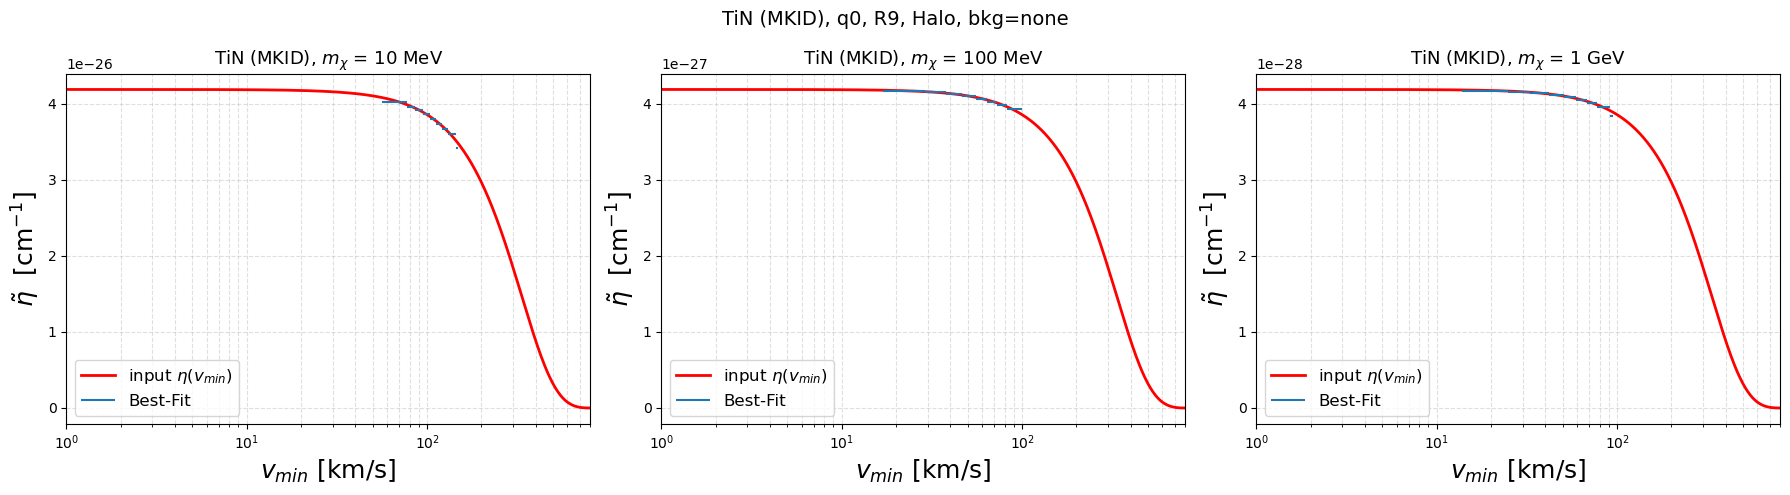

In [67]:
run_masses('TiN', q='0', nbins=9, eta='Halo')

### Light mediator (q2), 9 energy bins

signal     : [ 4760.13607329  5480.12561769  6303.298039    7170.30428959
  7987.61911826  8696.83230049  9354.07088979  9948.72885194
 10458.81202581]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M1_R9_Halo/flux.pdf
TiN q2 M1 R9: 9 E-bins x 164 v_min bins, peak flux 7.96e+02
signal     : [ 370.04530982  487.41133641  596.60389543  694.81071114  786.54163108
  871.65762579  950.10657318 1017.02590834 1078.95373977]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M2_R9_Halo/flux.pdf
TiN q2 M2 R9: 9 E-bins x 183 v_min bins, peak flux 8.20e+01
signal     : [ 36.99991699  48.80224283  59.55051072  69.63953341  78.65509971
  87.22830177  94.9333237  101.92040121 107.99943921]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_a

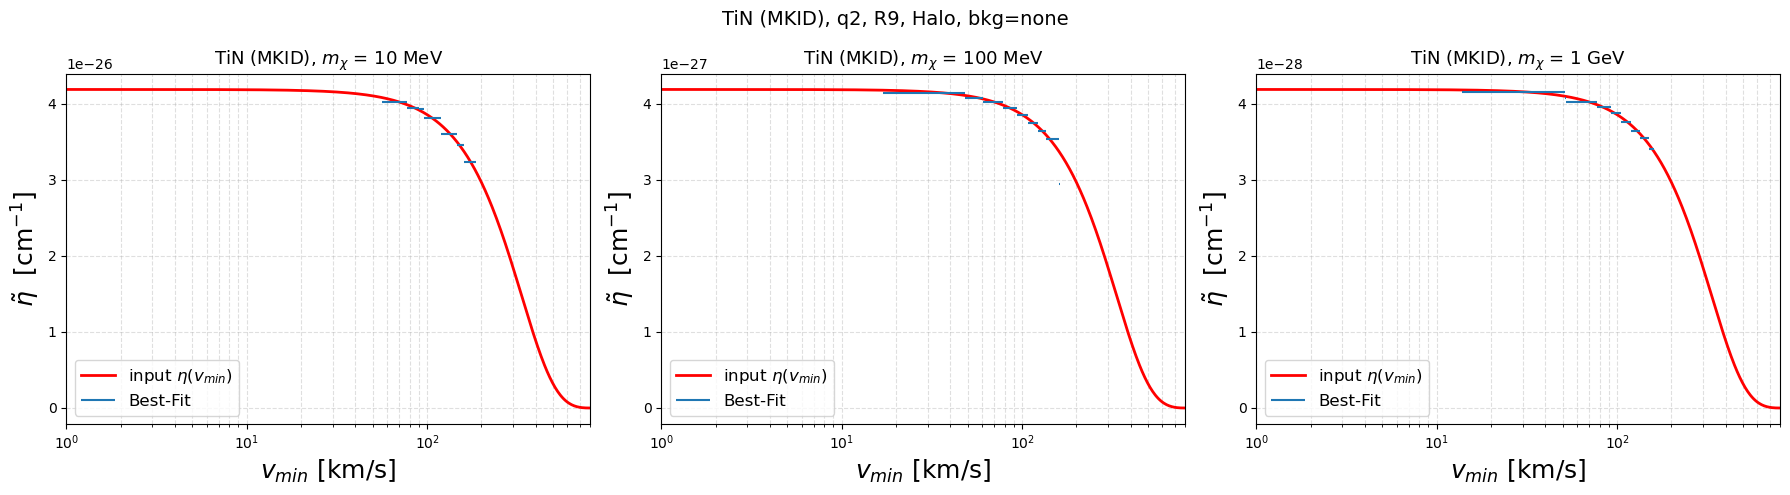

In [68]:
run_masses('TiN', q='2', nbins=9, eta='Halo')

## Mixture (best-fit) — sweep dark-disk fraction

`eta = (1-p)*Halo + p*Disk`. Each figure overlays 100% SHM (gray) and `p` x pure disk (green).

### Heavy mediator (q0), 5 energy bins

signal     : [1003.47474705 2976.78845775 3499.8136468  4145.95332486 4710.85604447]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R5_mix5/flux.pdf
TiN q0 M1 R5: 5 E-bins x 110 v_min bins, peak flux 8.41e+02
signal     : [ 74.26750692 234.58486007 315.67088781 395.67261475 470.08345701]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R5_mix5/flux.pdf
TiN q0 M2 R5: 5 E-bins x 99 v_min bins, peak flux 8.94e+01
signal     : [ 7.20449063 22.86414784 31.43461528 39.18982212 47.13388634]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R5_mix5/flux.pdf
TiN q0 M3 R5: 5 E-bins x 98 v_min bins, peak flux 8.96e+00


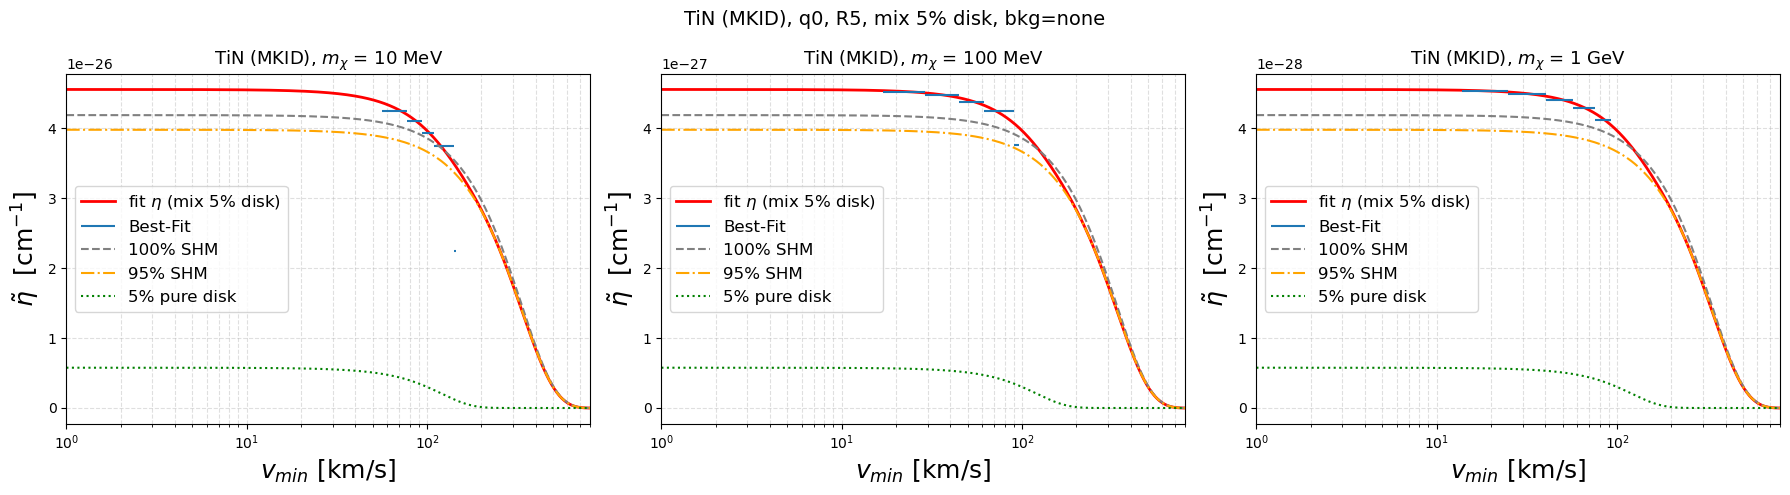

signal     : [1223.64691177 3477.46619112 3848.5187005  4256.7306468  4522.10866764]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R5_mix25/flux.pdf
TiN q0 M1 R5: 5 E-bins x 110 v_min bins, peak flux 1.03e+03
signal     : [ 97.33634113 304.04498695 400.11993149 485.15762667 551.33631549]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R5_mix25/flux.pdf
TiN q0 M2 R5: 5 E-bins x 99 v_min bins, peak flux 1.17e+02
signal     : [ 9.47110918 29.78764082 40.17322409 48.63881388 56.15133711]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R5_mix25/flux.pdf
TiN q0 M3 R5: 5 E-bins x 98 v_min bins, peak flux 1.18e+01


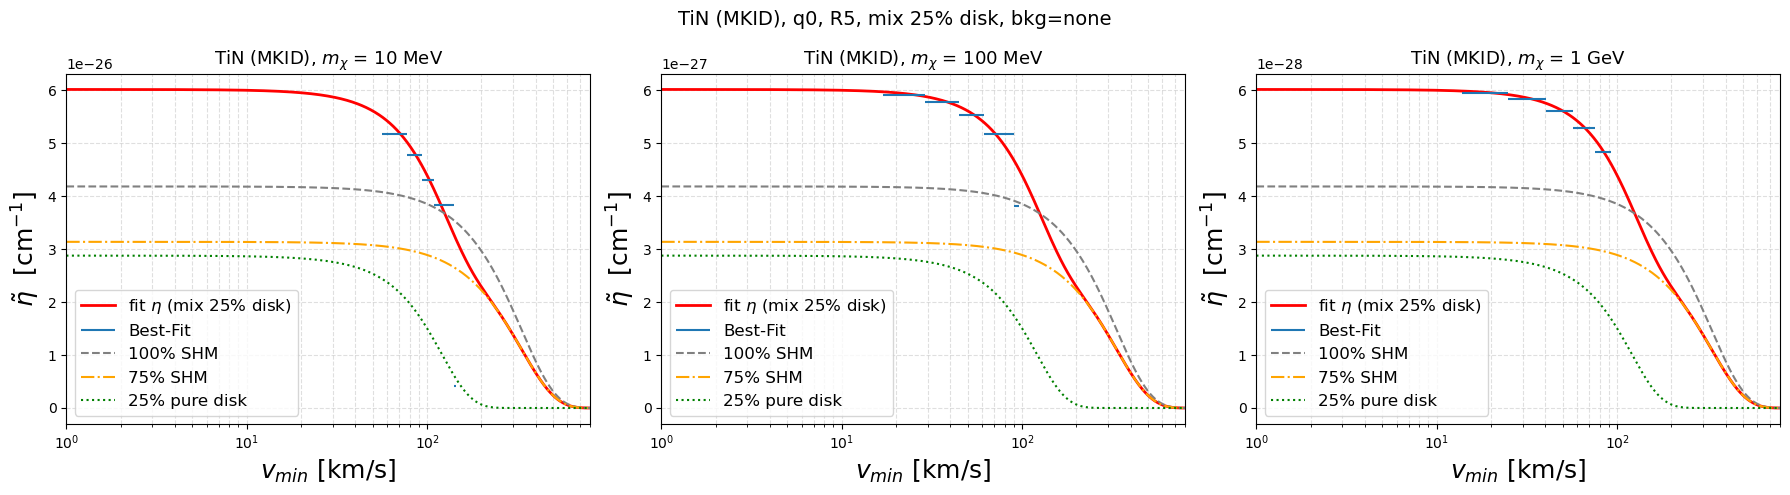

In [69]:
for p in DISK_FRACTIONS:
    run_masses('TiN', q='0', nbins=5, disk_fraction=p)

### Light mediator (q2), 5 energy bins

signal     : [ 5040.26536583 12261.23959459 14996.7348847  17548.11951183
 19297.76830921]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M1_R5_mix5/flux.pdf
TiN q2 M1 R5: 5 E-bins x 158 v_min bins, peak flux 8.43e+02
signal     : [ 399.94911997 1143.76399129 1522.7094814  1817.33844362 2039.7390126 ]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M2_R5_mix5/flux.pdf
TiN q2 M2 R5: 5 E-bins x 176 v_min bins, peak flux 8.87e+01
signal     : [ 40.03270845 114.62578465 152.5489349  182.50446111 205.57197776]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M3_R5_mix5/flux.pdf
TiN q2 M3 R5: 5 E-bins x 177 v_min bins, peak flux 8.89e+00


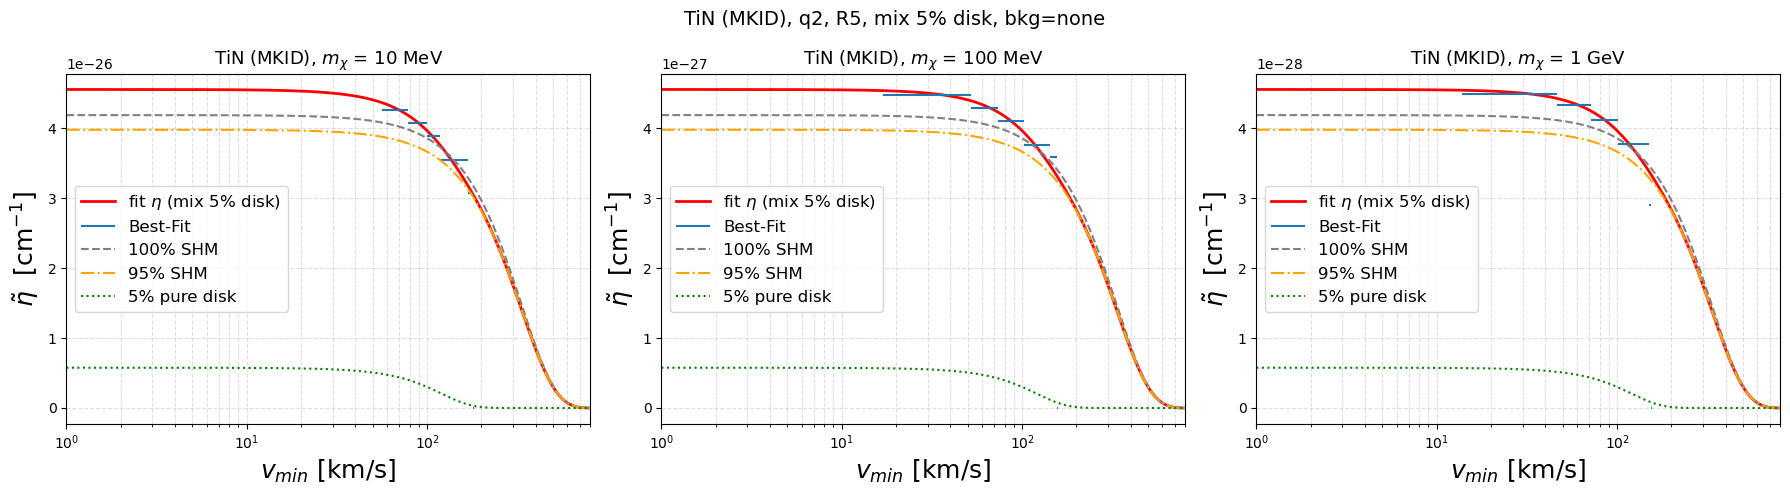

signal     : [ 6160.78253599 14204.54026001 15984.10686975 17115.04721862
 17451.17340506]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M1_R5_mix25/flux.pdf
TiN q2 M1 R5: 5 E-bins x 158 v_min bins, peak flux 1.03e+03
signal     : [ 519.56436057 1448.33425719 1834.49703094 2049.18361809 2135.04728149]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M2_R5_mix25/flux.pdf
TiN q2 M2 R5: 5 E-bins x 176 v_min bins, peak flux 1.15e+02
signal     : [ 52.16387429 145.91060404 185.39302511 208.22444309 218.09394169]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M3_R5_mix25/flux.pdf
TiN q2 M3 R5: 5 E-bins x 177 v_min bins, peak flux 1.16e+01


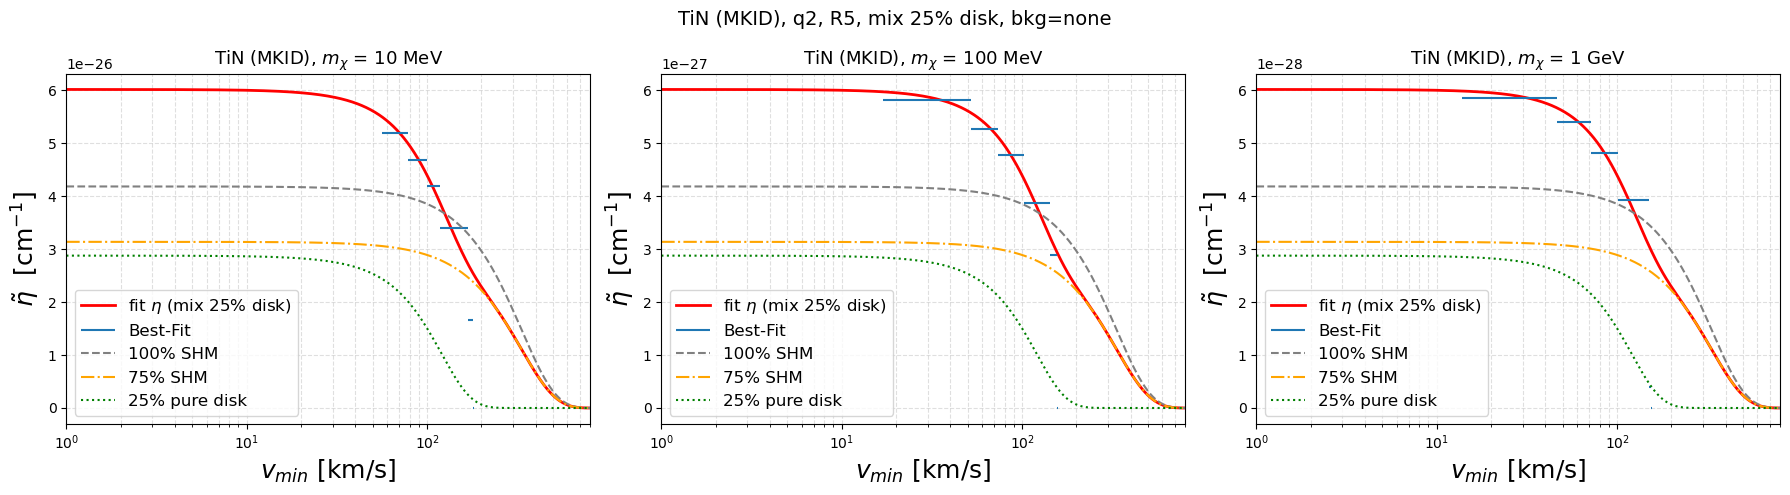

In [70]:
for p in DISK_FRACTIONS:
    run_masses('TiN', q='2', nbins=5, disk_fraction=p)

### Heavy mediator (q0), 9 energy bins

signal     : [1003.47474705 1292.17648339 1429.35151006 1684.67700045 1863.25367925
 2128.91328024 2325.62539643 2435.99072915 2578.50469629]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R9_mix5/flux.pdf
TiN q0 M1 R9: 9 E-bins x 115 v_min bins, peak flux 8.41e+02
signal     : [ 74.26750692  97.47780795 121.42520336 144.325838   168.54235133
 189.54355722 211.75500863 232.8132672  250.60972232]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R9_mix5/flux.pdf
TiN q0 M2 R9: 9 E-bins x 104 v_min bins, peak flux 8.94e+01
signal     : [ 7.20449063  9.4552428  11.87520869 14.40162088 16.62281577 18.96558496
 21.20856044 23.13759492 25.15861447]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-non

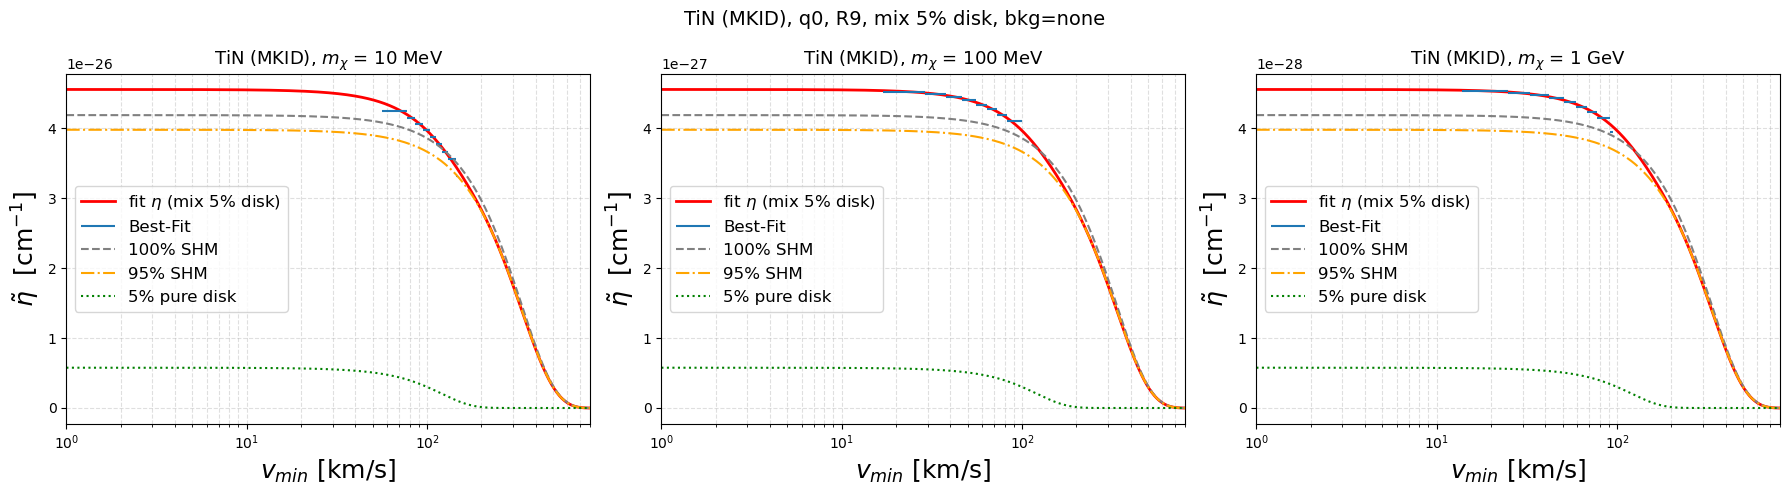

signal     : [1223.64691177 1532.84963529 1646.52468034 1878.6380834  2009.15612086
 2215.96574746 2338.66690581 2369.91697596 2429.6722549 ]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R9_mix25/flux.pdf
TiN q0 M1 R9: 9 E-bins x 115 v_min bins, peak flux 1.03e+03
signal     : [ 97.33634113 126.91602568 156.70736014 184.18901062 212.11319447
 234.6339331  257.04137349 276.33734601 290.19155206]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R9_mix25/flux.pdf
TiN q0 M2 R9: 9 E-bins x 104 v_min bins, peak flux 1.17e+02
signal     : [ 9.47110918 12.36600668 15.41753404 18.51705287 21.11720611 23.7375077
 26.07941163 27.88140122 29.62033824]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-no

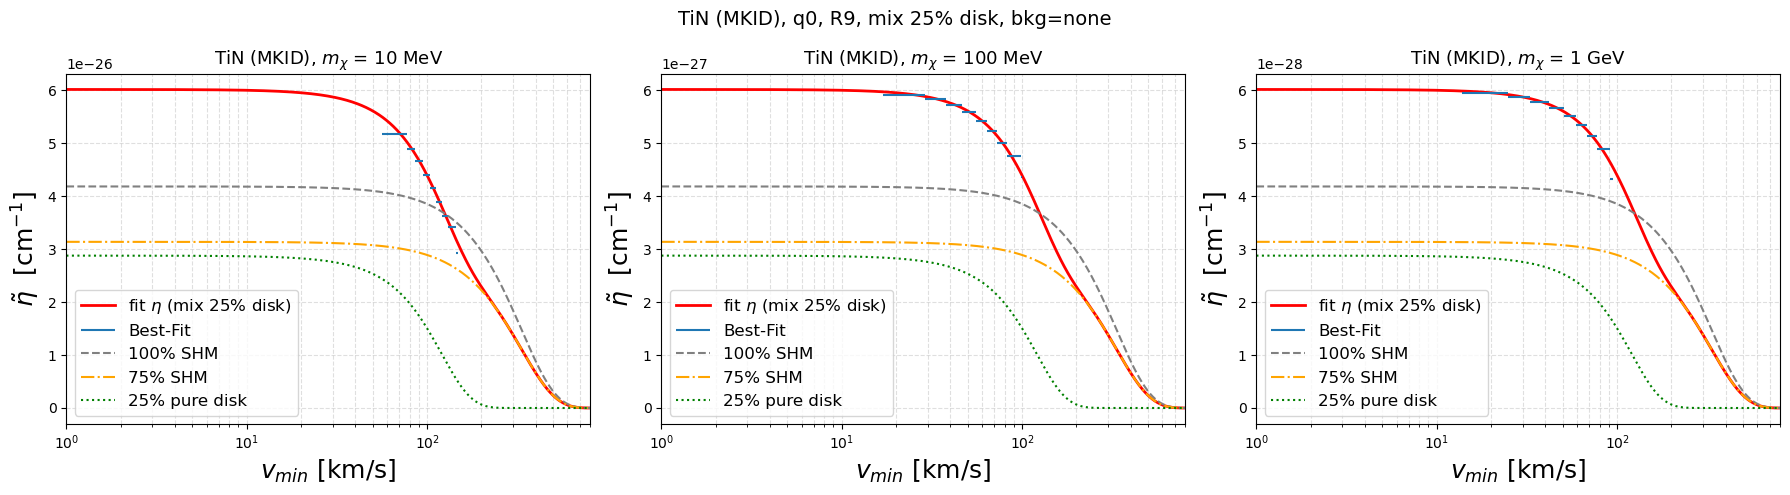

In [71]:
for p in DISK_FRACTIONS:
    run_masses('TiN', q='0', nbins=9, disk_fraction=p)

### Light mediator (q2), 9 energy bins

signal     : [ 5040.26536583  5740.21744572  6525.97568042  7335.050614
  8072.59715739  8691.18449118  9252.96324925  9754.49658505
 10178.74785266]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M1_R9_mix5/flux.pdf
TiN q2 M1 R9: 9 E-bins x 164 v_min bins, peak flux 8.43e+02
signal     : [ 399.94911997  524.09224611  637.18607322  736.05934326  825.46497034
  905.48948483  976.55436948 1034.51715908 1086.53501655]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M2_R9_mix5/flux.pdf
TiN q2 M2 R9: 9 E-bins x 183 v_min bins, peak flux 8.87e+01
signal     : [ 40.03270845  52.55584823  63.73393923  73.95813462  82.7953841
  90.9173127   97.93375662 104.05620455 109.16730244]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_anal

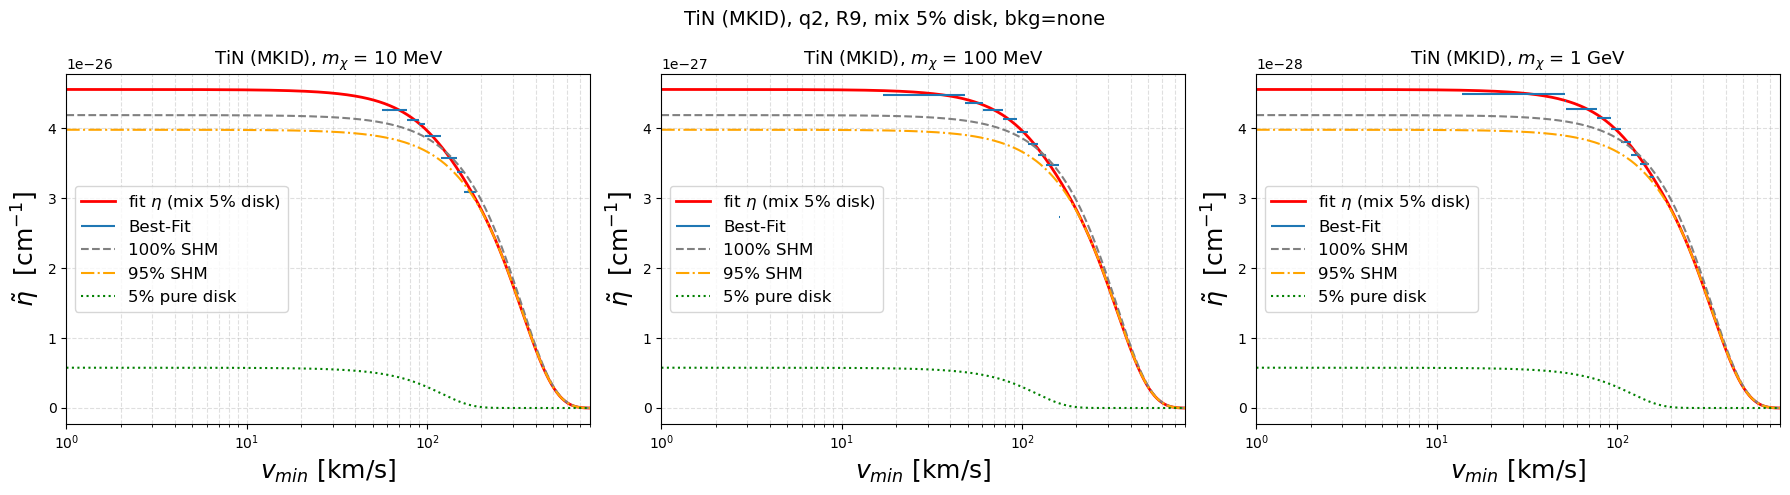

signal     : [6160.78253599 6780.58475783 7416.68624608 7994.03591164 8412.50931395
 8668.59325394 8848.53268708 8977.56751746 9058.49116004]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M1_R9_mix25/flux.pdf
TiN q2 M1 R9: 9 E-bins x 164 v_min bins, peak flux 1.03e+03
signal     : [ 519.56436057  670.81588493  799.51478438  901.05387176  981.15832738
 1040.81692098 1082.3455547  1104.48216206 1116.86012367]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M2_R9_mix25/flux.pdf
TiN q2 M2 R9: 9 E-bins x 183 v_min bins, peak flux 1.15e+02
signal     : [ 52.16387429  67.57026982  80.46765328  91.23253947  99.35652166
 105.6733564  109.93548829 112.59941792 113.83875534]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/

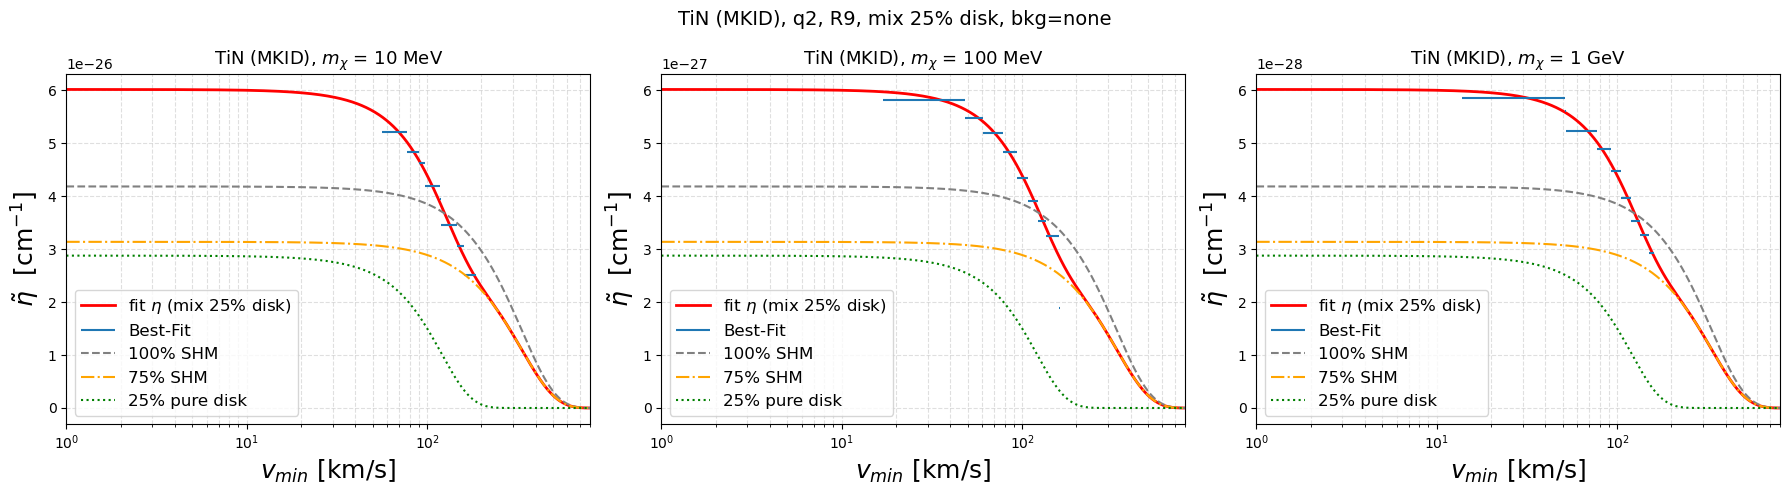

In [72]:
for p in DISK_FRACTIONS:
    run_masses('TiN', q='2', nbins=9, disk_fraction=p)

## Bound (Earth-bound thermal DM)

Dense (`rho_b = 1e14` GeV/cm^3), isotropic, cold (`v0 ~ 2.16` km/s at 1 GeV), `vesc = 11.2` km/s. Only **M3 (1 GeV)** is shown: the bound population is too slow to reach the `v_min` thresholds of the lighter masses (M1/M2 have no signal).

### Heavy mediator (q0), 5 energy bins

signal     : [ 6.637836   21.13327459 29.24996308 36.82757418 44.87952365]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R5_Bound/flux.pdf
TiN q0 M3 R5: 5 E-bins x 98 v_min bins, peak flux 8.26e+00


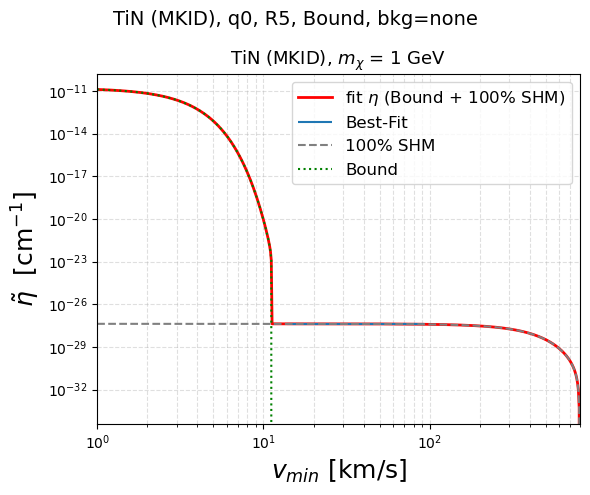

In [73]:
run_masses('TiN', q='0', nbins=5, eta='Bound', masses=('3',))

### Light mediator (q2), 5 energy bins

signal     : [ 36.99991699 106.8045798  144.33791235 176.07446562 202.44148678]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M3_R5_Bound/flux.pdf
TiN q2 M3 R5: 5 E-bins x 177 v_min bins, peak flux 8.22e+00


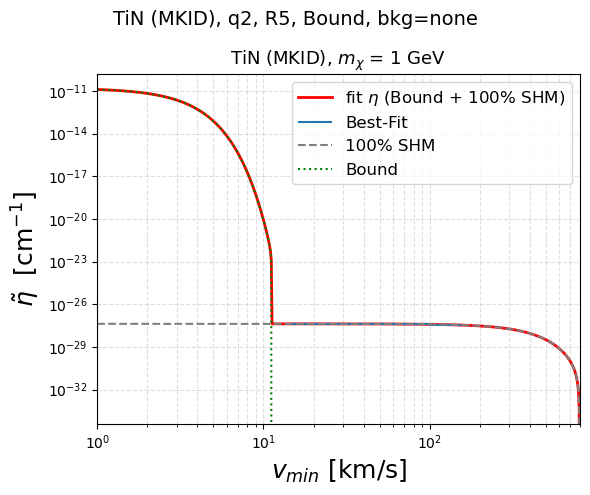

In [74]:
run_masses('TiN', q='2', nbins=5, eta='Bound', masses=('3',))

### Heavy mediator (q0), 9 energy bins

signal     : [ 6.637836    8.72755183 10.98962735 13.37276288 15.49921818 17.77260428
 19.99084764 21.95164335 24.04318352]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R9_Bound/flux.pdf
TiN q0 M3 R9: 9 E-bins x 102 v_min bins, peak flux 8.26e+00


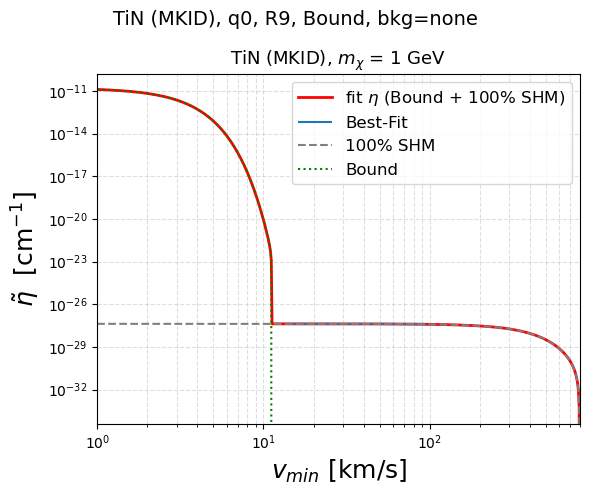

In [75]:
run_masses('TiN', q='0', nbins=9, eta='Bound', masses=('3',))

### Light mediator (q2), 9 energy bins

signal     : [ 36.99991699  48.80224283  59.55051072  69.63953341  78.65509971
  87.22830177  94.9333237  101.92040121 107.99943921]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M3_R9_Bound/flux.pdf
TiN q2 M3 R9: 9 E-bins x 184 v_min bins, peak flux 8.22e+00


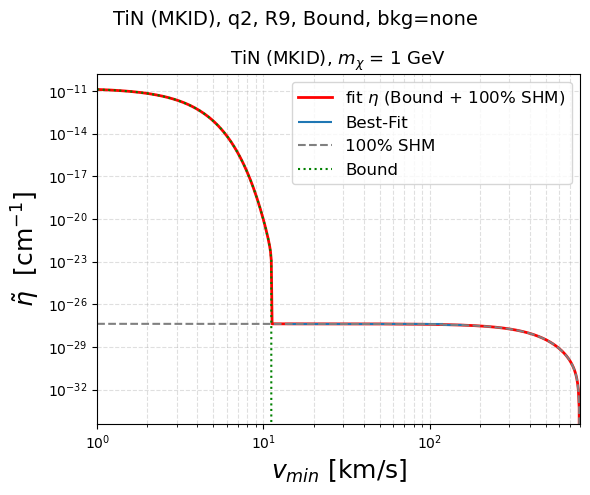

In [76]:
run_masses('TiN', q='2', nbins=9, eta='Bound', masses=('3',))